# US Live Cattle Futures Price Prediction
## CRISP-DM Capstone — Initial Report & EDA

**Author:** Brian Place
**Date:** July 2026
**Target Variable:** CME Live Cattle Front-Month Futures (cents/lb)
**Forecast Horizon:** 1 month ahead (regression)

---

## CRISP-DM Framework

This notebook follows the **Cross-Industry Standard Process for Data Mining (CRISP-DM)**:

| Phase | Description | Status |
|-------|-------------|--------|
| 1. Business Understanding | Define the problem, objectives, and success criteria | ✅ Complete |
| 2. Data Understanding | Collect and describe all data sources; initial EDA | ✅ Complete |
| 3. Data Preparation | Clean, merge, and engineer features | ✅ Complete |
| 4. Modeling | Build and evaluate regression models | 🔄 Baseline only (full models: next phase) |
| 5. Evaluation | Assess model performance and business value | ⬜ Next phase |
| 6. Deployment | Summarize findings and operationalize | ⬜ Next phase |

---
## Phase 1: Business Understanding

### 1.1 Problem Statement

US Live Cattle Futures, traded on the Chicago Mercantile Exchange (CME) under ticker **LE**, are the benchmark price for fed cattle in North America. These prices are driven by an interplay of USDA-reported supply fundamentals, input costs, and macro demand signals.

**Objective:** Develop a supervised regression model that predicts the **monthly closing price of CME Live Cattle Futures (cents/lb) one month ahead**, using USDA supply data and commodity market inputs as features.

### 1.2 Why This Matters

| Stakeholder | Use Case |
|-------------|----------|
| Cattle producers | Lock in revenue via futures hedges |
| Meatpackers | Procurement and margin planning |
| Food companies | Protein cost forecasting |
| Commodity traders | Systematic long/short signals |
| Restaurants | Menu, Marketing, Financial planning |


### 1.3 Success Criteria

| Metric | Target |
|--------|--------|
| R² (explained variance on test set) | ≥ 0.75 |
| RMSE | < 5 cents/lb |
| MAE | < 3 cents/lb |
| Directional accuracy | > 60% |

### 1.4 Scope
- **Target variable:** Monthly close — CME Live Cattle front-month futures (cents/lb)
- **Forecast horizon:** 1 month ahead
- **Historical range:** January 2005 – present
- **Train / test split:** 2005–2022 (train) | 2023–present (test)
- **Features:** USDA monthly supply data + corn futures + feeder cattle futures

---
## Phase 2: Data Understanding

### 2.1 Data Sources

| Source | Description | Coverage | Format |
|--------|-------------|----------|--------|
| **USDA ERS Meat Statistics** | Beef production, cattle slaughter, cold storage | 1921–2026, monthly | Excel (.xlsx) |
| **CME Live Cattle Futures** (LE=F) | Target — monthly close price (¢/lb) | 2005–present | yfinance (auto) |
| **CME Corn Futures** (ZC=F) | Key input cost (~60% of feed cost) | 2005–present | yfinance (auto) |
| **CME Feeder Cattle Futures** (GF=F) | Direct input cost to Live Cattle | 2005–present | yfinance (auto) |

### 2.2 Data Dictionary

**USDA Supply Features**

| Column | Description | Units |
|--------|-------------|-------|
| `comm_beef_prod` | Commercial beef production | Million lbs / month |
| `comm_cattle_slaughter` | Commercial cattle slaughter | 1,000 head / month |
| `beef_cold_storage` | Beginning beef cold storage stocks | Million lbs |

**Futures Price Features**

| Column | Description | Units |
|--------|-------------|-------|
| `live_cattle_price` | CME Live Cattle front-month close | ¢ / lb ← **TARGET** |
| `corn_price` | CME Corn front-month close | ¢ / bushel |
| `feeder_cattle_price` | CME Feeder Cattle front-month close | ¢ / lb |



In [43]:
# ── Imports & Configuration ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import re
import os
import warnings
import yfinance as yf

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size']      = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

DOWNLOADS  = os.path.expanduser('~/Downloads/')
CAPSTONE   = os.path.expanduser('~/Python/Capstone/')
USDA_FILE  = CAPSTONE + 'MeatStatsFull.xlsx'
START_DATE = '2005-01-01'

print("Libraries loaded.")
print(f"USDA file exists: {os.path.exists(USDA_FILE)}")

Libraries loaded.
USDA file exists: True


### 2.3 Load USDA Data

In [44]:
# ── USDA data loader ─────────────────────────────────────────────────────────
MONTH_RE = re.compile(r'^[A-Z][a-z]{2}-\d{4}$')

def parse_usda_monthly(df):
    """Filter to monthly rows (format: Mon-YYYY) and set date index."""
    df = df[df.iloc[:, 0].apply(
        lambda x: bool(MONTH_RE.match(str(x))) if pd.notna(x) else False
    )].copy()
    df['date'] = pd.to_datetime(df.iloc[:, 0], format='%b-%Y')
    return df.set_index('date').sort_index().loc[START_DATE:]

# Production (commercial beef = column index 1)
raw_prod  = pd.read_excel(USDA_FILE, sheet_name='RedMeatPoultry_Prod-Full',  header=2)
prod      = parse_usda_monthly(raw_prod)
beef_prod = pd.to_numeric(prod.iloc[:, 1], errors='coerce').rename('comm_beef_prod')

# Cold storage (beef = column index 1)
raw_cold  = pd.read_excel(USDA_FILE, sheet_name='ColdStorage-Full',          header=1)
cold      = parse_usda_monthly(raw_cold)
cold_beef = pd.to_numeric(cold.iloc[:, 1], errors='coerce').rename('beef_cold_storage')

# Slaughter counts (commercial cattle = column index 1)
raw_sltr  = pd.read_excel(USDA_FILE, sheet_name='SlaughterCounts-Full',      header=2)
sltr      = parse_usda_monthly(raw_sltr)
sltr_ct   = pd.to_numeric(sltr.iloc[:, 1], errors='coerce').rename('comm_cattle_slaughter')

usda = pd.concat([beef_prod, cold_beef, sltr_ct], axis=1).dropna()
print(f"USDA: {usda.shape[0]} months  ({usda.index.min().strftime('%Y-%m')} → {usda.index.max().strftime('%Y-%m')})")
usda.head()

USDA: 257 months  (2005-01 → 2026-05)


,comm_beef_prod,beef_cold_storage,comm_cattle_slaughter
date,,,
2005-01-01,1915.6,484.276,2528.1
2005-02-01,1767.4,453.261,2342.9
2005-03-01,2041.7,400.240,2725.1
2005-04-01,1887.8,372.323,2560.3
2005-05-01,2074.0,329.425,2793.3


### 2.4 Load Futures Price Data

In [45]:
# ── Futures prices via yfinance (always current — no manual download needed) ──
def load_yf_monthly(ticker, col_name, unit_multiplier=1.0):
    df = yf.download(ticker, start=START_DATE, interval='1mo',
                     progress=False, auto_adjust=True)
    if df.empty:
        return None
    s = df['Close'].squeeze() * unit_multiplier
    s.name = col_name
    s.index = pd.to_datetime(s.index).to_period('M').to_timestamp('M')
    return s.dropna().to_frame()

# Keep load_macrotrends for optional CSV sources (DXY, cutout)
def load_macrotrends(path, col_name, unit_multiplier=1.0):
    with open(path, 'r', encoding='utf-8-sig') as f:
        lines = f.readlines()
    start = next(
        i for i, ln in enumerate(lines)
        if ln.strip().lower().lstrip('"').startswith('date')
    )
    df = pd.read_csv(path, skiprows=start, encoding='utf-8-sig')
    df = df.iloc[:, :2]
    df.columns = ['date', col_name]
    df['date'] = pd.to_datetime(df['date'])
    df[col_name] = pd.to_numeric(df[col_name], errors='coerce') * unit_multiplier
    df = df.set_index('date').sort_index().loc[START_DATE:]
    df = df.resample('ME').last()
    return df

le     = load_yf_monthly('LE=F', 'live_cattle_price')   # ¢/lb
corn   = load_yf_monthly('ZC=F', 'corn_price')           # ¢/bu (already in cents)
feeder = load_yf_monthly('GF=F', 'feeder_cattle_price')  # ¢/lb

if le is not None and corn is not None and feeder is not None:
    futures = pd.concat([le, corn, feeder], axis=1)
    print(f"Futures: {futures.shape[0]} months  ({futures.index.min().strftime('%Y-%m')} → {futures.index.max().strftime('%Y-%m')})")
    print(futures.tail(3).round(2))
else:
    print("⚠  Could not fetch futures data from yfinance — check your internet connection.")
    futures = None

Futures: 221 months  (2005-01 → 2026-07)
            live_cattle_price  corn_price  feeder_cattle_price
Date                                                          
2026-05-31             248.25      446.75               348.42
2026-06-30             258.20      412.75               364.60
2026-07-31             222.50      487.25               341.45


### 2.5 Initial Inspection

In [46]:
print("=" * 56)
print("USDA SUPPLY FEATURES — Descriptive Statistics")
print("=" * 56)
print(usda.describe().round(2))

if futures is not None:
    print()
    print("=" * 56)
    print("FUTURES PRICE FEATURES — Descriptive Statistics")
    print("=" * 56)
    print(futures.describe().round(2))

USDA SUPPLY FEATURES — Descriptive Statistics
       comm_beef_prod  beef_cold_storage  comm_cattle_slaughter
count          257.00             257.00                 257.00
mean          2182.33             453.03                2711.64
std            155.55              44.26                 210.02
min           1767.40             318.19                2170.20
25%           2073.80             424.93                2569.50
50%           2200.30             450.78                2730.90
75%           2298.40             484.29                2863.00
max           2506.70             567.89                3159.40

FUTURES PRICE FEATURES — Descriptive Statistics
       live_cattle_price  corn_price  feeder_cattle_price
count             221.00      221.00               221.00
mean              128.14      450.95               162.33
std                39.63      144.53                63.14
min                79.20      187.50                91.00
25%                96.95      358.00   

### 2.6 Data Quality Assessment

Missing values — USDA:
comm_beef_prod           0
beef_cold_storage        0
comm_cattle_slaughter    0
dtype: int64

Missing values — Futures:
live_cattle_price      0
corn_price             0
feeder_cattle_price    0
dtype: int64


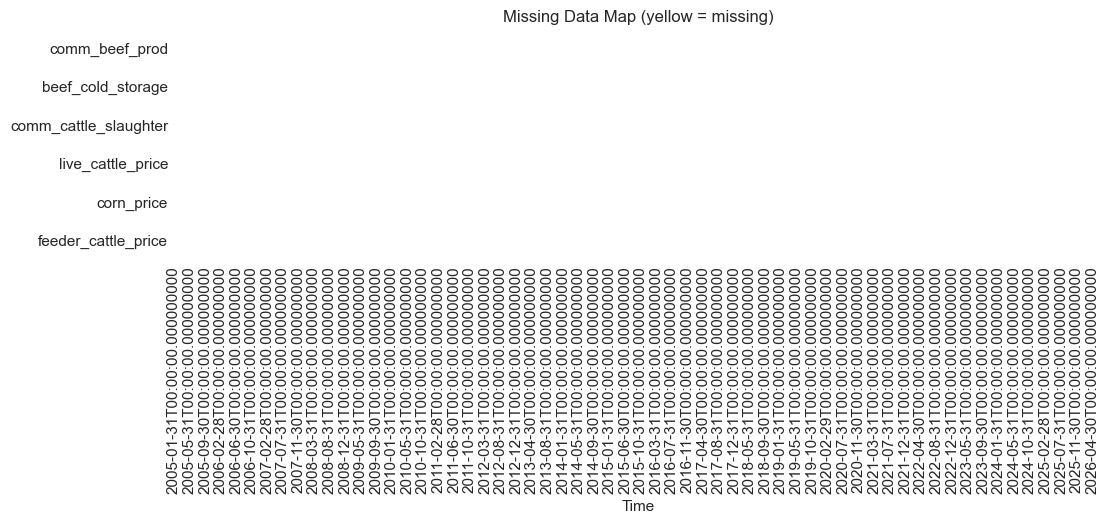

In [47]:
print("Missing values — USDA:")
print(usda.isnull().sum())

if futures is not None:
    print("\nMissing values — Futures:")
    print(futures.isnull().sum())

all_data = pd.concat([usda, futures], axis=1) if futures is not None else usda
all_data_me = all_data.copy()
all_data_me.index = all_data_me.index.to_period('M').to_timestamp('M')

fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(all_data_me.isnull().T, cmap='YlOrRd', cbar=False,
            ax=ax, linewidths=0.3, yticklabels=all_data_me.columns)
ax.set_title('Missing Data Map (yellow = missing)', fontsize=12)
ax.set_xlabel('Time')
plt.tight_layout()
plt.show()

---
### 2.7 Additional Feature Data Sources

Four high-value datasets are added to address the key gaps in the baseline feature set:

| Dataset | Gap Filled | Expected Impact |
|---------|-----------|-----------------|
| **USDA Cattle on Feed** | Supply timing — placements today = slaughter 4–6 months ahead | High |
| **CFTC Commitments of Traders (COT)** | Speculative positioning — managed money moves prices short-term | High |
| **US Dollar Index (DXY)** | Export demand — strong dollar suppresses foreign beef buying | Medium |
| **Choice Beef Cutout Value** | Packer margin — cutout premium drives cattle bid prices | Medium |

> **Download instructions:**
>
> **Cattle on Feed** — go to `quickstats.nass.usda.gov` → Livestock → Cattle → ON FEED, PLACED, MARKETED → National level → Download CSV. Save as `cattle_on_feed.csv`
>
> **CFTC COT** — go to `cftc.gov` → Market Data → Commitments of Traders → Legacy COT → Historical Compressed → download annual TXT files, combine, save as `cftc_cot_cattle.csv`
>
> **Dollar Index** — go to `fred.stlouisfed.org` → search `DTWEXBGS` → Download → CSV. Save as `dollar_index.csv`
>
> **Choice Cutout** — go to `investing.com` → search "US Beef Cutout" or download from USDA AMS boxed beef reports. Save as `choice_cutout.csv`

In [48]:
# ── Additional data file paths ────────────────────────────────────────────────
COF_FILE     = CAPSTONE + 'cattle_on_feed.csv'
COT_FILE     = DOWNLOADS + 'cftc_cot_cattle.csv'
DXY_FILE     = CAPSTONE + 'dollar_index.csv'
CUTOUT_FILE  = DOWNLOADS + 'choice_cutout.csv'

addl_available = {
    'Cattle on Feed': os.path.exists(COF_FILE),
    'CFTC COT':       os.path.exists(COT_FILE),
    'Dollar Index':   os.path.exists(DXY_FILE),
    'Choice Cutout':  os.path.exists(CUTOUT_FILE),
}
print("Additional data file status:")
for name, avail in addl_available.items():
    print(f"  {'✅' if avail else '⬜'} {name}")

Additional data file status:
  ✅ Cattle on Feed
  ⬜ CFTC COT
  ✅ Dollar Index
  ⬜ Choice Cutout


#### Cattle on Feed (USDA NASS QuickStats)

In [49]:
# ── Load Cattle on Feed (USDA NASS Quick Stats format) ───────────────────────
# Source: quickstats.nass.usda.gov
#   Commodity: CATTLE | Data Item: CATTLE, ON FEED - INVENTORY
#   Program: SURVEY | Period Type: Point in Time | Geo Level: NATIONAL
# File has 2 observations per year: FIRST OF JAN and FIRST OF JUL
# We interpolate linearly to monthly to align with the rest of the dataset.
cof = None
if os.path.exists(COF_FILE):
    try:
        raw_cof = pd.read_csv(COF_FILE, encoding='utf-8-sig', thousands=',')
        raw_cof.columns = raw_cof.columns.str.strip().str.lower().str.replace(' ', '_')

        # Filter to inventory rows only
        item_col = next(c for c in raw_cof.columns if 'data_item' in c)
        inv = raw_cof[raw_cof[item_col].str.upper().str.contains('INVENTORY', na=False)].copy()

        # Parse "FIRST OF JAN" / "FIRST OF JUL" + year → datetime
        PERIOD_MAP = {
            'FIRST OF JAN': '01', 'FIRST OF FEB': '02', 'FIRST OF MAR': '03',
            'FIRST OF APR': '04', 'FIRST OF MAY': '05', 'FIRST OF JUN': '06',
            'FIRST OF JUL': '07', 'FIRST OF AUG': '08', 'FIRST OF SEP': '09',
            'FIRST OF OCT': '10', 'FIRST OF NOV': '11', 'FIRST OF DEC': '12',
            'END OF DEC':   '12',
        }
        inv['month'] = inv['period'].str.upper().str.strip().map(PERIOD_MAP)
        inv = inv.dropna(subset=['month'])
        inv['date'] = pd.to_datetime(inv['year'].astype(str) + '-' + inv['month'] + '-01')
        inv['value'] = pd.to_numeric(inv['value'].astype(str).str.replace(',',''), errors='coerce')
        inv = inv.dropna(subset=['date','value']).set_index('date').sort_index()['value']
        inv = inv[~inv.index.duplicated(keep='last')]  # drop any duplicate dates

        # Reindex to full monthly range and interpolate between Jan/Jul anchors
        full_idx = pd.date_range(inv.index.min(), inv.index.max(), freq='MS')
        inv_monthly = inv.reindex(full_idx).interpolate(method='time')
        inv_monthly.index = inv_monthly.index.to_period('M').to_timestamp('M')

        cof = inv_monthly.rename('cattle_inventory').to_frame().loc[START_DATE:]
        print(f"Cattle Inventory: {len(cof)} months  "
              f"({cof.index.min().date()} → {cof.index.max().date()})")
        print(f"Range: {cof['cattle_inventory'].min()/1e6:.2f}M – "
              f"{cof['cattle_inventory'].max()/1e6:.2f}M head")
        print(cof.tail(3).round(0))
    except Exception as e:
        print(f"⚠  Could not parse cattle_on_feed.csv: {e}")
        cof = None
else:
    print("⬜ cattle_on_feed.csv not found — skipping.")

Cattle Inventory: 253 months  (2005-01-31 → 2026-01-31)
Range: 11.60M – 14.83M head
            cattle_inventory
2025-11-30        13566803.0
2025-12-31        13705047.0
2026-01-31        13847900.0


#### CFTC Commitments of Traders — Live Cattle

In [50]:
# ── Load CFTC COT data ────────────────────────────────────────────────────────
# Download from cftc.gov > Market Data > Commitments of Traders > Legacy COT
# Historical files: fut_disagg_txt_YYYY.zip  (Disaggregated Futures Only)
# Filter to LIVE CATTLE - CHICAGO MERCANTILE EXCHANGE
# Key columns:
#   As_of_Date_In_Form_YYMMDD  — report date
#   M_Money_Positions_Long_All  — managed money long
#   M_Money_Positions_Short_All — managed money short
cot = None
if os.path.exists(COT_FILE):
    raw_cot = pd.read_csv(COT_FILE, low_memory=False)
    raw_cot.columns = raw_cot.columns.str.strip()

    # Filter to Live Cattle
    market_col = next((c for c in raw_cot.columns
                       if 'market' in c.lower() or 'name' in c.lower()), raw_cot.columns[0])
    lc_mask = raw_cot[market_col].str.upper().str.contains('LIVE CATTLE', na=False)
    lc = raw_cot[lc_mask].copy()

    # Parse date
    date_col = next((c for c in lc.columns if 'date' in c.lower()), None)
    if date_col:
        lc['date'] = pd.to_datetime(lc[date_col], errors='coerce')
    lc = lc.dropna(subset=['date']).set_index('date').sort_index()

    # Extract managed money net position (long - short)
    long_col  = next((c for c in lc.columns if 'money' in c.lower() and 'long'  in c.lower()), None)
    short_col = next((c for c in lc.columns if 'money' in c.lower() and 'short' in c.lower()), None)

    if long_col and short_col:
        lc['mm_net'] = (pd.to_numeric(lc[long_col],  errors='coerce') -
                        pd.to_numeric(lc[short_col], errors='coerce'))
        cot = lc[['mm_net']].loc[START_DATE:]
        # COT is weekly — resample to month-end
        cot = cot.resample('ME').last()
        # COT index: normalize net position to 0-100% of historical range
        roll_min = cot['mm_net'].rolling(52, min_periods=12).min()
        roll_max = cot['mm_net'].rolling(52, min_periods=12).max()
        cot['cot_index'] = ((cot['mm_net'] - roll_min) /
                             (roll_max - roll_min).replace(0, np.nan)) * 100
        print(f"CFTC COT: {cot.shape[0]} months  ({cot.index.min().date()} → {cot.index.max().date()})")
        print(cot.tail(3).round(1))
    else:
        print(f"⚠  Could not find managed money columns. Available: {[c for c in lc.columns[:20]]}")
        cot = None
else:
    print("⬜ cftc_cot_cattle.csv not found — skipping.")

⬜ cftc_cot_cattle.csv not found — skipping.


#### US Dollar Index (DXY — Investing.com)

In [51]:
# ── Load Dollar Index ─────────────────────────────────────────────────────────
# Investing.com format: UTF-8 BOM, 7 columns (Date, Price, Open, High, Low, Vol., Change%)
# Same format as live_cattle_futures.csv — use load_macrotrends() which handles this.
dxy = None
if os.path.exists(DXY_FILE):
    try:
        dxy = load_macrotrends(DXY_FILE, 'dxy')
        print(f"Dollar Index: {dxy.shape[0]} months  ({dxy.index.min().date()} → {dxy.index.max().date()})")
        print(dxy.tail(3).round(2))
    except Exception as e:
        print(f"⚠  Could not load dollar_index.csv: {e}")
        dxy = None
else:
    print("⬜ dollar_index.csv not found — skipping.")

Dollar Index: 240 months  (2006-08-31 → 2026-07-31)
               dxy
date              
2026-05-31   98.91
2026-06-30  101.19
2026-07-31  101.14


#### Choice Beef Cutout Value

In [52]:
# ── Load Choice Beef Cutout ───────────────────────────────────────────────────
# Source: USDA AMS boxed beef report, or Investing.com
# Expected: two columns — date and cutout value ($/cwt)
cutout = None
if os.path.exists(CUTOUT_FILE):
    with open(CUTOUT_FILE, 'r', encoding='utf-8-sig') as f:
        lines = f.readlines()
    start = next(
        (i for i, ln in enumerate(lines)
         if ln.strip().lower().lstrip('"').startswith('date')), 0
    )
    raw_cut = pd.read_csv(CUTOUT_FILE, skiprows=start, encoding='utf-8-sig')
    raw_cut = raw_cut.iloc[:, :2]
    raw_cut.columns = ['date', 'choice_cutout']
    raw_cut['date'] = pd.to_datetime(raw_cut['date'], errors='coerce')
    raw_cut['choice_cutout'] = pd.to_numeric(raw_cut['choice_cutout'], errors='coerce')
    cutout = (raw_cut.dropna()
                     .set_index('date').sort_index()
                     .loc[START_DATE:])
    cutout = cutout.resample('ME').last()
    print(f"Choice Cutout: {cutout.shape[0]} months  ({cutout.index.min().date()} → {cutout.index.max().date()})")
    print(cutout.tail(3).round(2))
else:
    print("⬜ choice_cutout.csv not found — skipping.")

⬜ choice_cutout.csv not found — skipping.


#### Additional Features vs Live Cattle Price

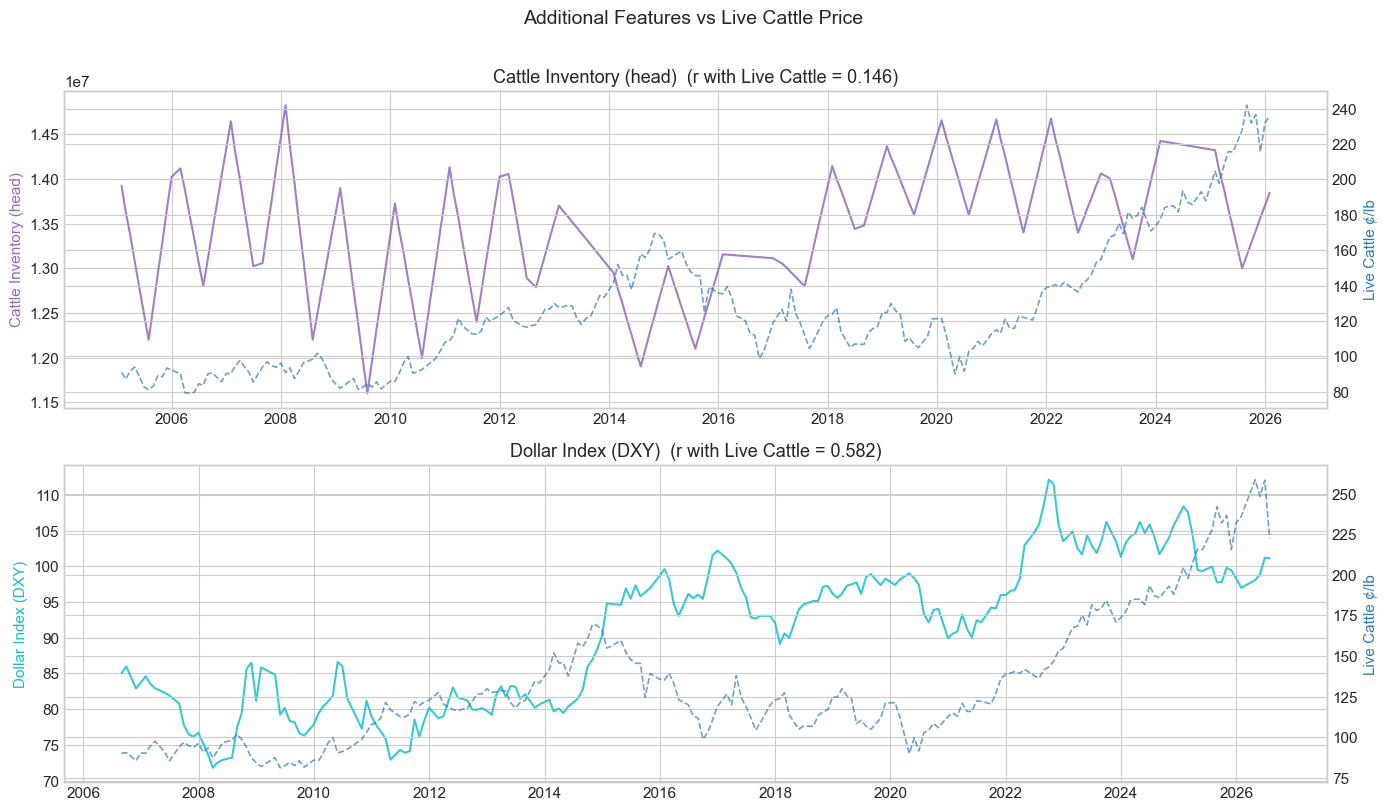

In [53]:
if futures is not None:
    addl_series = [
        (cof[['cattle_inventory']] if cof    is not None else None, 'Cattle Inventory (head)',       '#9467bd'),
        (cot[['mm_net']]           if cot    is not None else None, 'COT Mgd Money Net (contracts)', '#e377c2'),
        (dxy                       if dxy    is not None else None, 'Dollar Index (DXY)',             '#17becf'),
        (cutout                    if cutout is not None else None, 'Choice Cutout ($/cwt)',          '#bcbd22'),
    ]
    avail = [(df, label, color) for df, label, color in addl_series if df is not None]

    if avail:
        fig, axes = plt.subplots(len(avail), 1, figsize=(14, 4 * len(avail)))
        if len(avail) == 1:
            axes = [axes]
        le_me = le.copy()
        le_me.index = le_me.index.to_period('M').to_timestamp('M')

        for ax, (df, label, color) in zip(axes, avail):
            df_me = df.copy()
            df_me.index = df_me.index.to_period('M').to_timestamp('M')
            merged_tmp = df_me.join(le_me, how='inner').dropna()
            col = df_me.columns[0]

            ax2 = ax.twinx()
            ax.plot(merged_tmp.index, merged_tmp[col],
                    color=color, linewidth=1.5, alpha=0.85, label=label)
            ax2.plot(merged_tmp.index, merged_tmp['live_cattle_price'],
                     color='#2c7bb6', linewidth=1.2, linestyle='--', alpha=0.7,
                     label='Live Cattle Price')
            r = merged_tmp[col].corr(merged_tmp['live_cattle_price'])
            ax.set_title(f'{label}  (r with Live Cattle = {r:.3f})')
            ax.set_ylabel(label, color=color)
            ax2.set_ylabel('Live Cattle ¢/lb', color='#2c7bb6')
            ax.xaxis.set_major_locator(mdates.YearLocator(2))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

        plt.suptitle('Additional Features vs Live Cattle Price', fontsize=14, y=1.01)
        plt.tight_layout()
        plt.show()
    else:
        print("No additional datasets loaded yet — download files and rerun.")

---
### 2.8 Price History & Year-over-Year Change

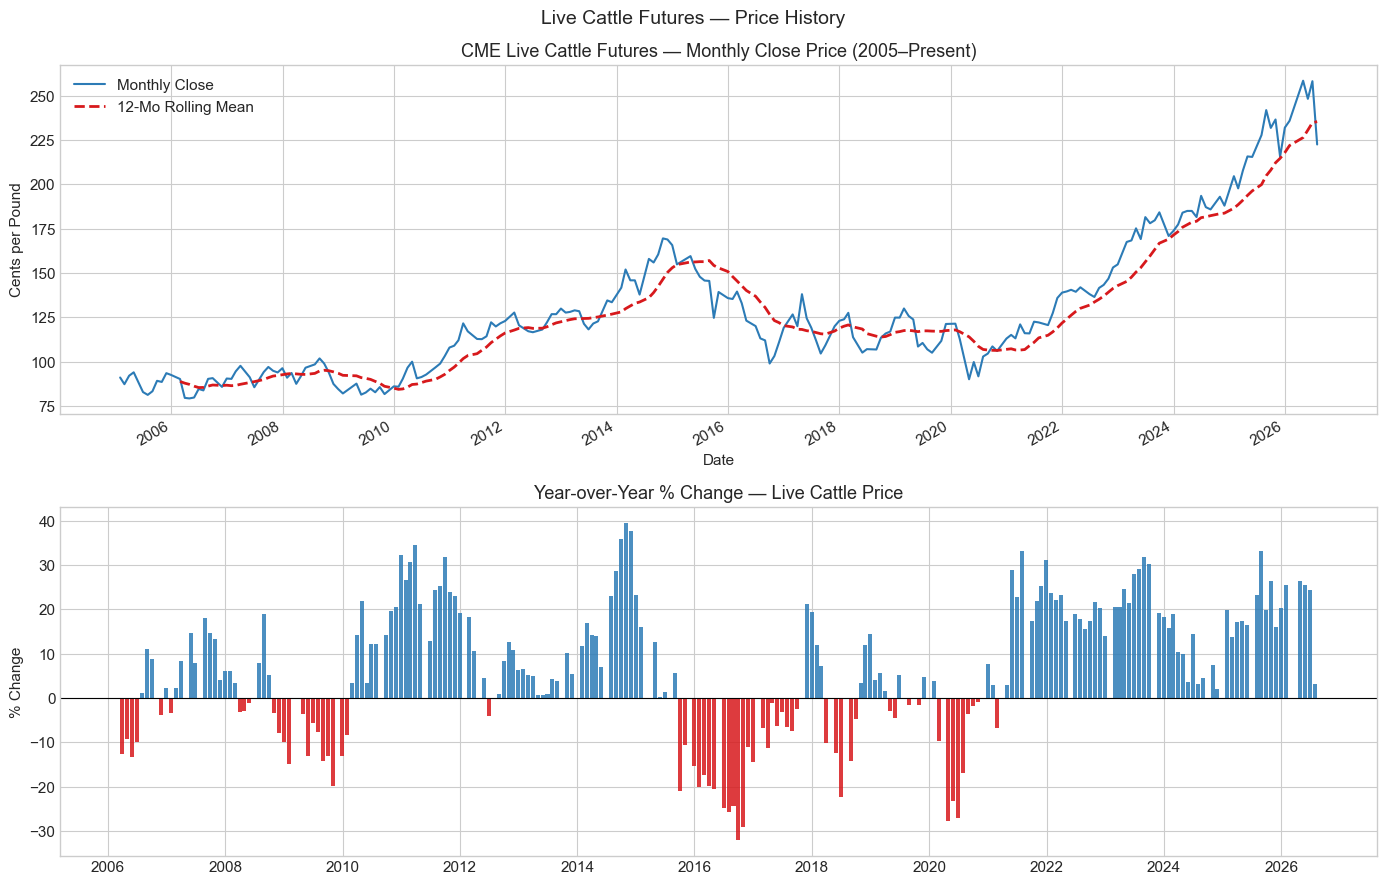

In [54]:
if futures is not None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 9))

    # Price over time + rolling mean
    ax = axes[0]
    le['live_cattle_price'].plot(ax=ax, color='#2c7bb6', linewidth=1.5, label='Monthly Close')
    le['live_cattle_price'].rolling(12).mean().plot(
        ax=ax, color='#d7191c', linewidth=2, linestyle='--', label='12-Mo Rolling Mean')
    ax.set_title('CME Live Cattle Futures — Monthly Close Price (2005–Present)')
    ax.set_ylabel('Cents per Pound')
    ax.legend()
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # YoY % change
    ax2 = axes[1]
    yoy = le['live_cattle_price'].pct_change(12) * 100
    colors = ['#2c7bb6' if v >= 0 else '#d7191c' for v in yoy.fillna(0)]
    ax2.bar(yoy.index, yoy, color=colors, width=25, alpha=0.85)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_title('Year-over-Year % Change — Live Cattle Price')
    ax2.set_ylabel('% Change')
    ax2.xaxis.set_major_locator(mdates.YearLocator(2))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.suptitle('Live Cattle Futures — Price History', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Futures data not loaded — skipping price history chart.")

### 2.9 Price Distribution & Seasonality

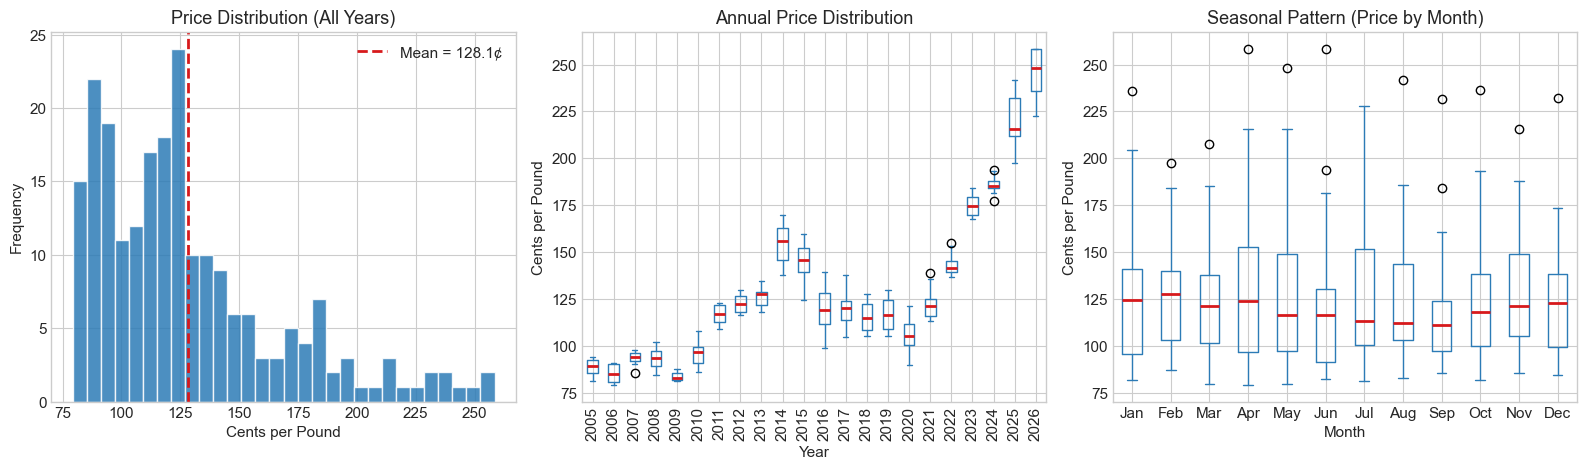

Descriptive Statistics — Live Cattle Price:
count    221.00
mean     128.14
std       39.63
min       79.20
25%       96.95
50%      120.00
75%      141.90
max      258.48
Name: live_cattle_price, dtype: float64

Skewness: 1.250 | Kurtosis: 1.214


In [55]:
if futures is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']
    le_df = le.copy()
    le_df['year']  = le_df.index.year
    le_df['month'] = le_df.index.month

    # Histogram
    axes[0].hist(le_df['live_cattle_price'], bins=30, color='#2c7bb6',
                 edgecolor='white', alpha=0.85)
    axes[0].set_title('Price Distribution (All Years)')
    axes[0].set_xlabel('Cents per Pound')
    axes[0].set_ylabel('Frequency')
    mean_price = le_df['live_cattle_price'].mean()
    axes[0].axvline(mean_price, color='#d7191c', linewidth=2, linestyle='--',
                    label=f'Mean = {mean_price:.1f}¢')
    axes[0].legend()

    # Box by year
    le_df.boxplot(column='live_cattle_price', by='year', ax=axes[1],
                  boxprops=dict(color='#2c7bb6'),
                  medianprops=dict(color='#d7191c', linewidth=2),
                  whiskerprops=dict(color='#2c7bb6'),
                  capprops=dict(color='#2c7bb6'))
    axes[1].set_title('Annual Price Distribution')
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Cents per Pound')
    plt.sca(axes[1])
    plt.xticks(rotation=90)

    # Box by month (seasonality)
    le_df.boxplot(column='live_cattle_price', by='month', ax=axes[2],
                  boxprops=dict(color='#2c7bb6'),
                  medianprops=dict(color='#d7191c', linewidth=2),
                  whiskerprops=dict(color='#2c7bb6'),
                  capprops=dict(color='#2c7bb6'))
    axes[2].set_title('Seasonal Pattern (Price by Month)')
    axes[2].set_xlabel('Month')
    axes[2].set_ylabel('Cents per Pound')
    axes[2].set_xticklabels(month_labels)

    plt.suptitle('')
    plt.tight_layout()
    plt.show()

    print("Descriptive Statistics — Live Cattle Price:")
    print(le['live_cattle_price'].describe().round(2))
    skew = le['live_cattle_price'].skew()
    kurt = le['live_cattle_price'].kurt()
    print(f"\nSkewness: {skew:.3f} | Kurtosis: {kurt:.3f}")

### 2.10 Autocorrelation (ACF)

The ACF shows how strongly current price correlates with its own lagged values — essential for understanding whether the series has memory and whether lagged price should be a model feature.

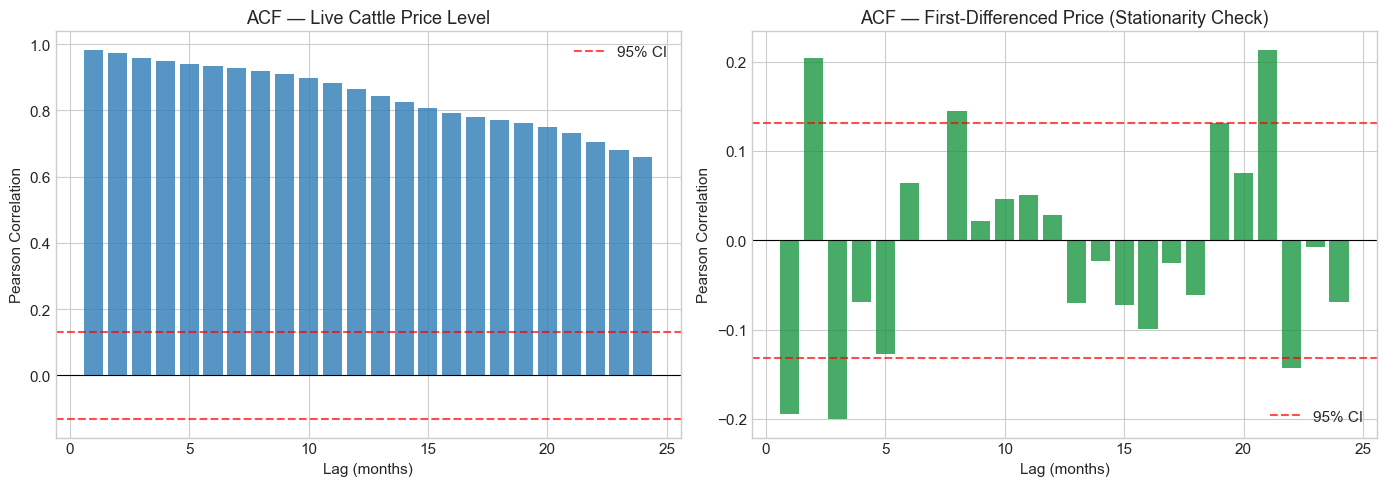

Lag-1  autocorrelation (price level): 0.983
Lag-12 autocorrelation (seasonal):    0.863

Interpretation: High lag-1 autocorrelation → lagged price is a strong feature.


In [56]:
if futures is not None:
    price = le['live_cattle_price'].dropna()
    lags  = list(range(1, 25))

    acf_vals  = [price.autocorr(lag=l) for l in lags]
    price_diff = price.diff().dropna()
    acf_diff  = [price_diff.autocorr(lag=l) for l in lags]
    ci = 1.96 / np.sqrt(len(price))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(lags, acf_vals, color='#2c7bb6', alpha=0.8)
    axes[0].axhline(0,   color='black', linewidth=0.8)
    axes[0].axhline( ci, color='red', linestyle='--', alpha=0.7, label='95% CI')
    axes[0].axhline(-ci, color='red', linestyle='--', alpha=0.7)
    axes[0].set_title('ACF — Live Cattle Price Level')
    axes[0].set_xlabel('Lag (months)')
    axes[0].set_ylabel('Pearson Correlation')
    axes[0].legend()

    axes[1].bar(lags, acf_diff, color='#1a9641', alpha=0.8)
    axes[1].axhline(0,   color='black', linewidth=0.8)
    axes[1].axhline( ci, color='red', linestyle='--', alpha=0.7, label='95% CI')
    axes[1].axhline(-ci, color='red', linestyle='--', alpha=0.7)
    axes[1].set_title('ACF — First-Differenced Price (Stationarity Check)')
    axes[1].set_xlabel('Lag (months)')
    axes[1].set_ylabel('Pearson Correlation')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"Lag-1  autocorrelation (price level): {price.autocorr(1):.3f}")
    print(f"Lag-12 autocorrelation (seasonal):    {price.autocorr(12):.3f}")
    print(f"\nInterpretation: High lag-1 autocorrelation → lagged price is a strong feature.")

---
### 2.11 Supply-Side Features (USDA Data)

#### Time Series

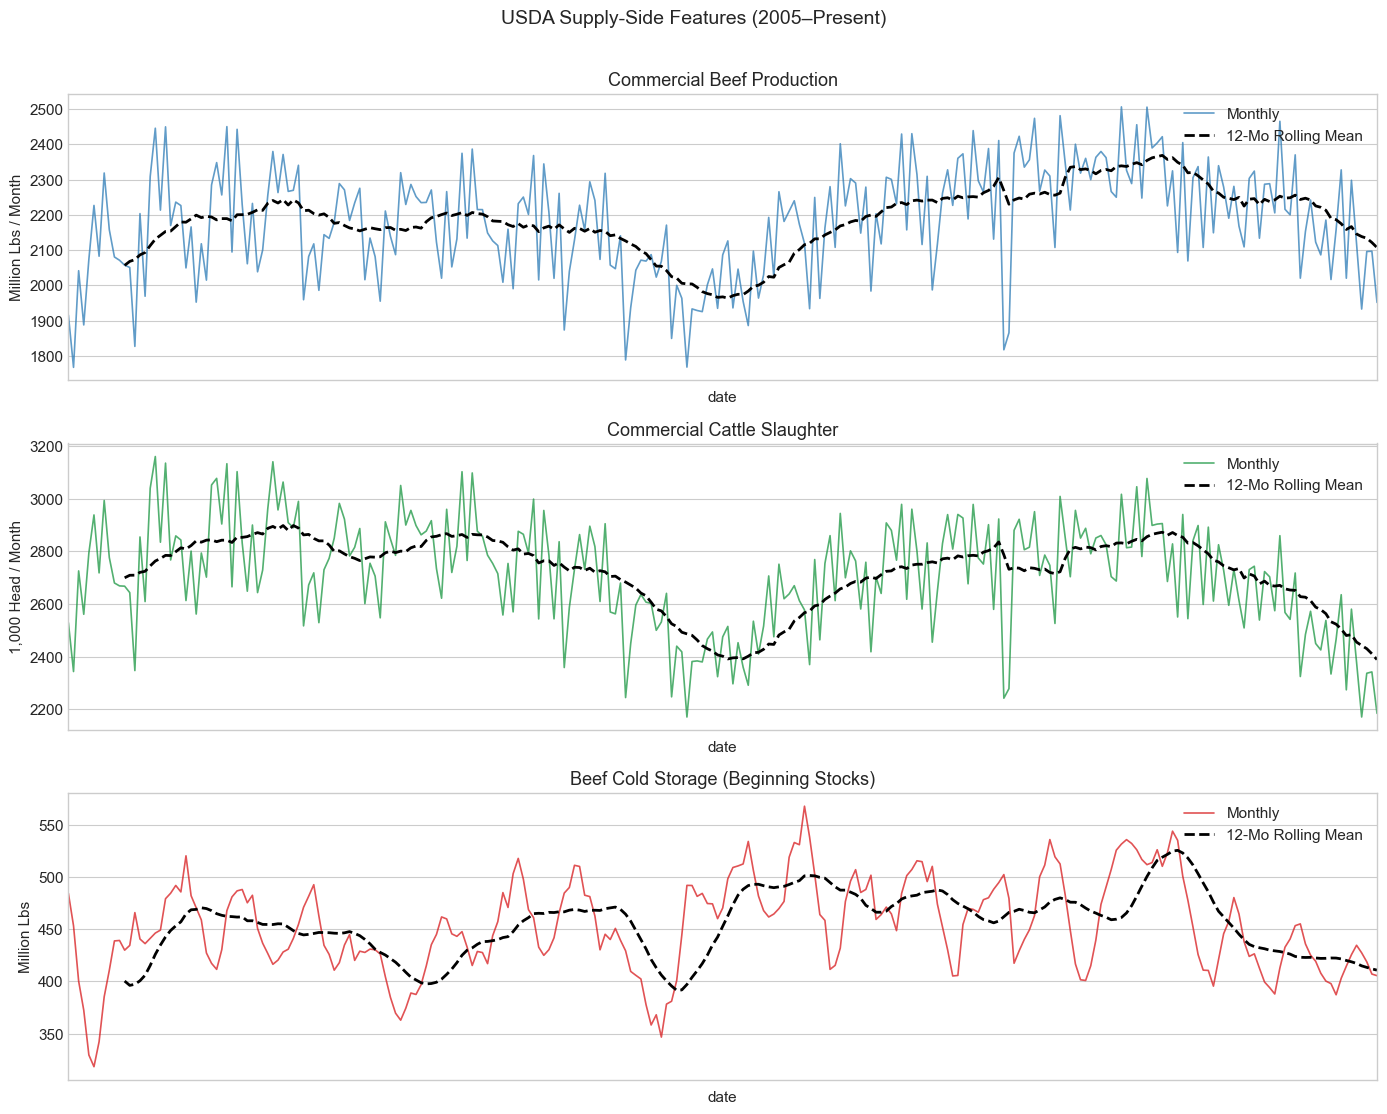

In [57]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

meta = [
    ('comm_beef_prod',        'Commercial Beef Production',  'Million Lbs / Month', '#2c7bb6'),
    ('comm_cattle_slaughter', 'Commercial Cattle Slaughter', '1,000 Head / Month',  '#1a9641'),
    ('beef_cold_storage',     'Beef Cold Storage (Beginning Stocks)', 'Million Lbs', '#d7191c'),
]

for ax, (col, title, ylabel, color) in zip(axes, meta):
    usda[col].plot(ax=ax, color=color, linewidth=1.2, alpha=0.75, label='Monthly')
    usda[col].rolling(12).mean().plot(
        ax=ax, color='black', linewidth=2, linestyle='--', label='12-Mo Rolling Mean')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper right')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('USDA Supply-Side Features (2005–Present)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### Seasonality in Supply Features

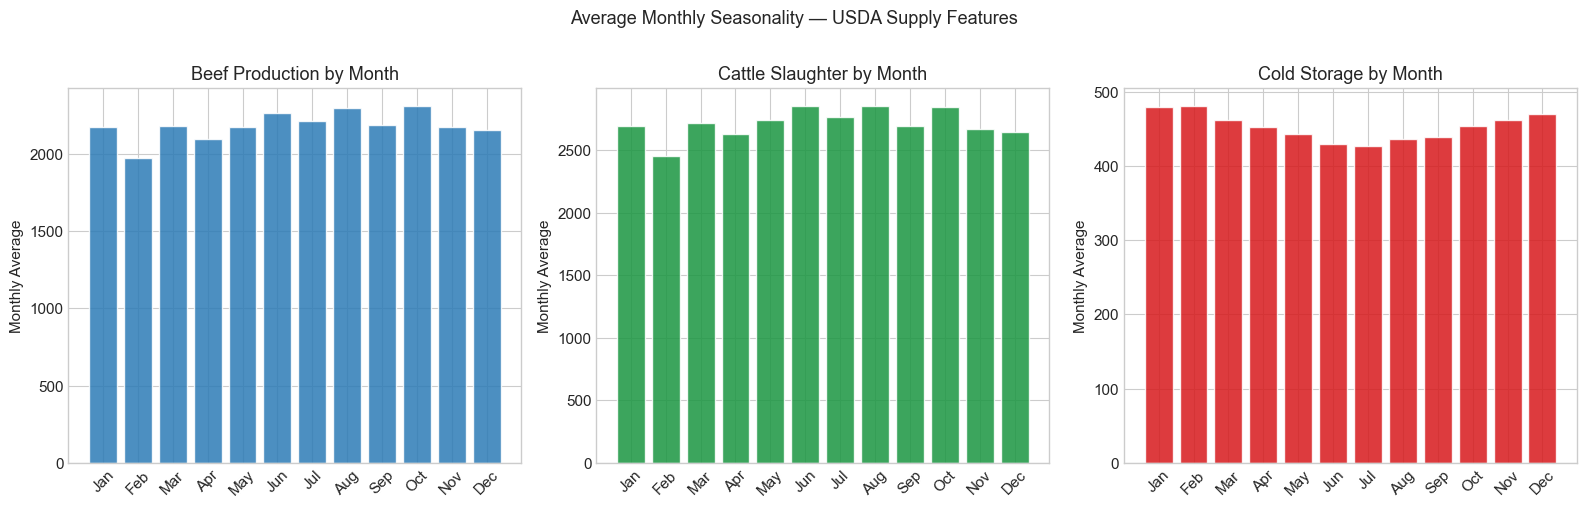

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

usda_m = usda.copy()
usda_m['month'] = usda_m.index.month

for ax, (col, title, color) in zip(axes, [
    ('comm_beef_prod',        'Beef Production by Month',    '#2c7bb6'),
    ('comm_cattle_slaughter', 'Cattle Slaughter by Month',   '#1a9641'),
    ('beef_cold_storage',     'Cold Storage by Month',       '#d7191c'),
]):
    avg = usda_m.groupby('month')[col].mean()
    ax.bar(range(1, 13), avg, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, rotation=45)
    ax.set_ylabel('Monthly Average')

plt.suptitle('Average Monthly Seasonality — USDA Supply Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

#### Supply Features vs Live Cattle Price

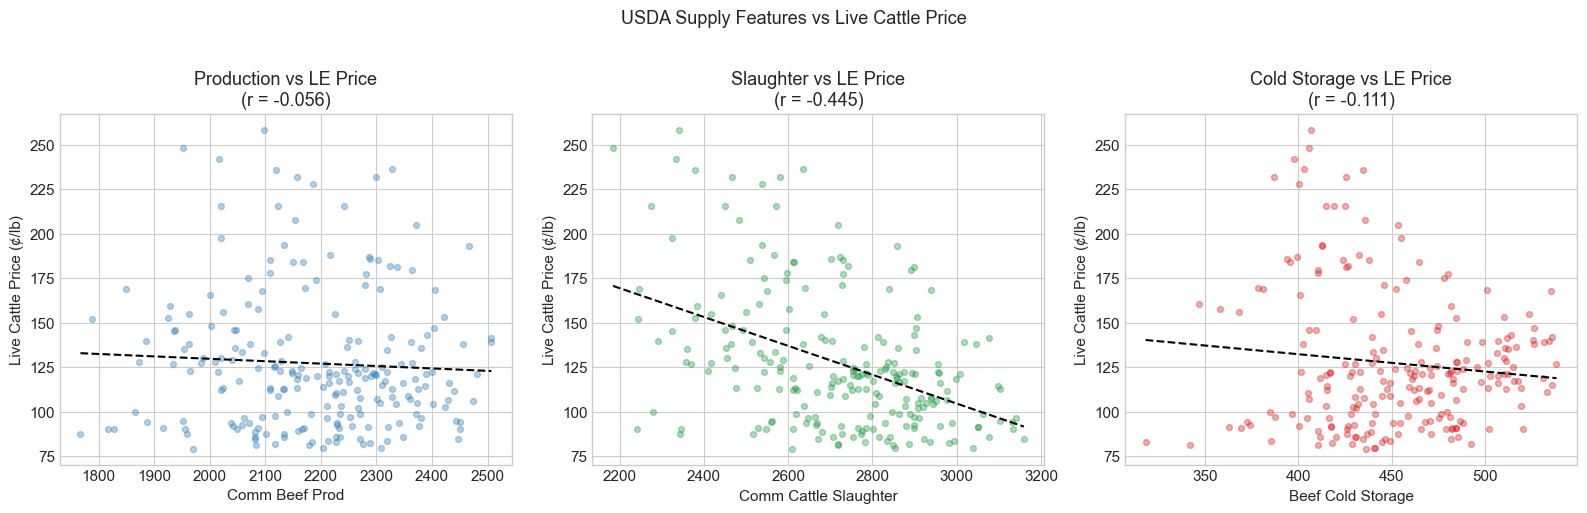

In [59]:
if futures is not None:
    # Align indices to month-end before joining
    usda_me   = usda.copy()
    usda_me.index = usda_me.index.to_period('M').to_timestamp('M')
    futures_me = futures.copy()
    futures_me.index = futures_me.index.to_period('M').to_timestamp('M')
    combined  = usda_me.join(futures_me, how='inner').dropna()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for ax, (xcol, title, color) in zip(axes, [
        ('comm_beef_prod',        'Production vs LE Price',    '#2c7bb6'),
        ('comm_cattle_slaughter', 'Slaughter vs LE Price',     '#1a9641'),
        ('beef_cold_storage',     'Cold Storage vs LE Price',  '#d7191c'),
    ]):
        valid = combined[[xcol, 'live_cattle_price']].dropna()
        ax.scatter(valid[xcol], valid['live_cattle_price'],
                   alpha=0.35, color=color, s=18)
        m, b = np.polyfit(valid[xcol], valid['live_cattle_price'], 1)
        x_line = np.linspace(valid[xcol].min(), valid[xcol].max(), 100)
        ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--')
        r = valid[xcol].corr(valid['live_cattle_price'])
        ax.set_title(f'{title}\n(r = {r:.3f})')
        ax.set_xlabel(xcol.replace('_', ' ').title())
        ax.set_ylabel('Live Cattle Price (¢/lb)')

    plt.suptitle('USDA Supply Features vs Live Cattle Price', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Futures data not loaded — skipping supply vs price scatter plots.")

---
### 2.12 Market Input Features — Corn & Feeder Cattle Futures

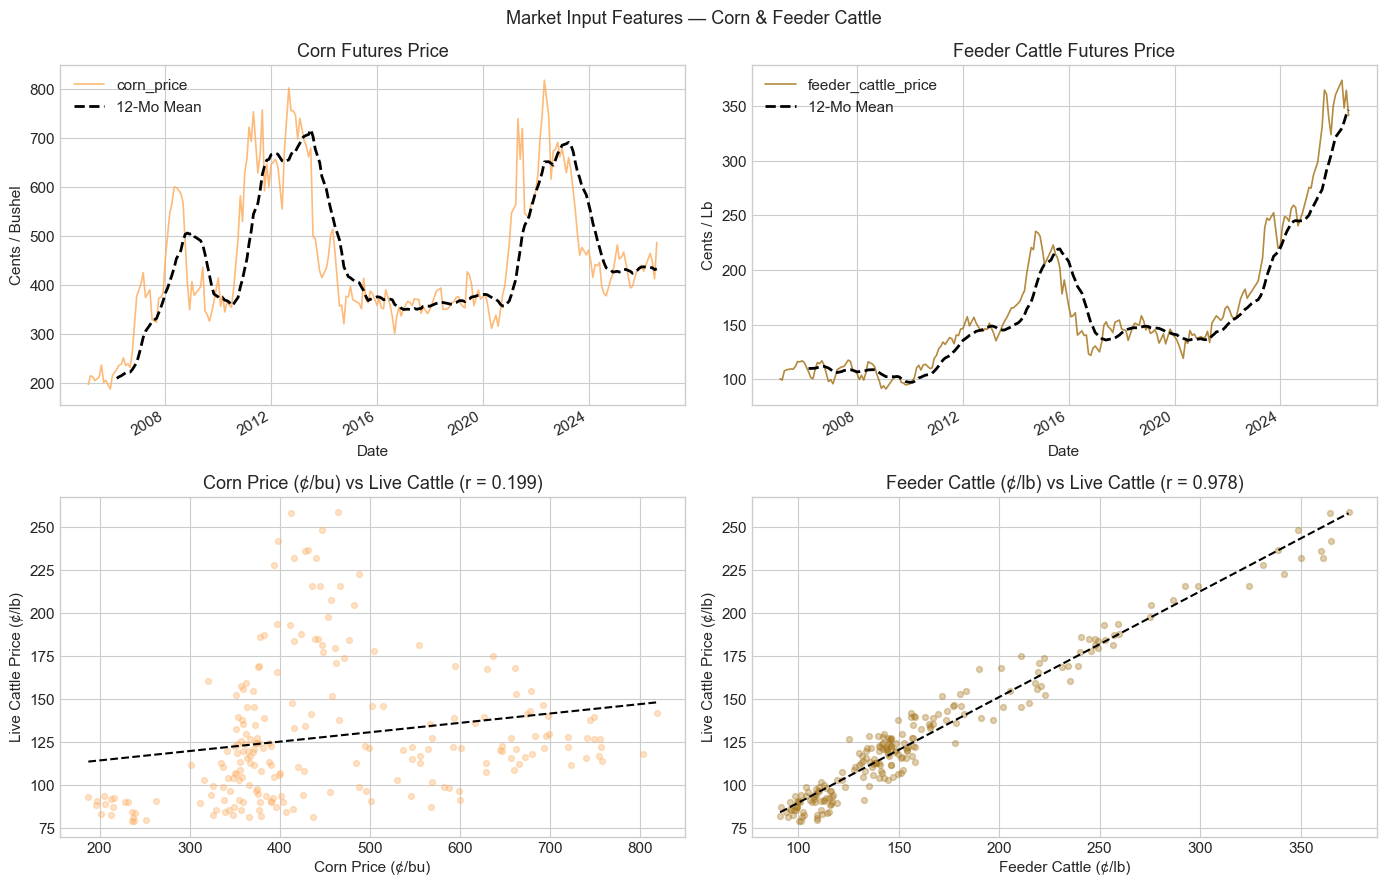

In [60]:
if futures is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # Corn over time
    futures['corn_price'].plot(ax=axes[0, 0], color='#fdae61', linewidth=1.2, alpha=0.85)
    futures['corn_price'].rolling(12).mean().plot(
        ax=axes[0, 0], color='black', linewidth=2, linestyle='--', label='12-Mo Mean')
    axes[0, 0].set_title('Corn Futures Price')
    axes[0, 0].set_ylabel('Cents / Bushel')
    axes[0, 0].legend()

    # Feeder cattle over time
    futures['feeder_cattle_price'].plot(ax=axes[0, 1], color='#a6761d', linewidth=1.2, alpha=0.85)
    futures['feeder_cattle_price'].rolling(12).mean().plot(
        ax=axes[0, 1], color='black', linewidth=2, linestyle='--', label='12-Mo Mean')
    axes[0, 1].set_title('Feeder Cattle Futures Price')
    axes[0, 1].set_ylabel('Cents / Lb')
    axes[0, 1].legend()

    for (xcol, label, color, ax) in [
        ('corn_price',           'Corn Price (¢/bu)',       '#fdae61', axes[1, 0]),
        ('feeder_cattle_price',  'Feeder Cattle (¢/lb)',    '#a6761d', axes[1, 1]),
    ]:
        valid = futures[[xcol, 'live_cattle_price']].dropna()
        ax.scatter(valid[xcol], valid['live_cattle_price'],
                   alpha=0.35, color=color, s=18)
        m, b = np.polyfit(valid[xcol], valid['live_cattle_price'], 1)
        x_line = np.linspace(valid[xcol].min(), valid[xcol].max(), 100)
        ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--')
        r = valid[xcol].corr(valid['live_cattle_price'])
        ax.set_title(f'{label} vs Live Cattle (r = {r:.3f})')
        ax.set_xlabel(label)
        ax.set_ylabel('Live Cattle Price (¢/lb)')

    plt.suptitle('Market Input Features — Corn & Feeder Cattle', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("Futures data not loaded — skipping market feature plots.")

---
### 2.13 Correlation Matrix

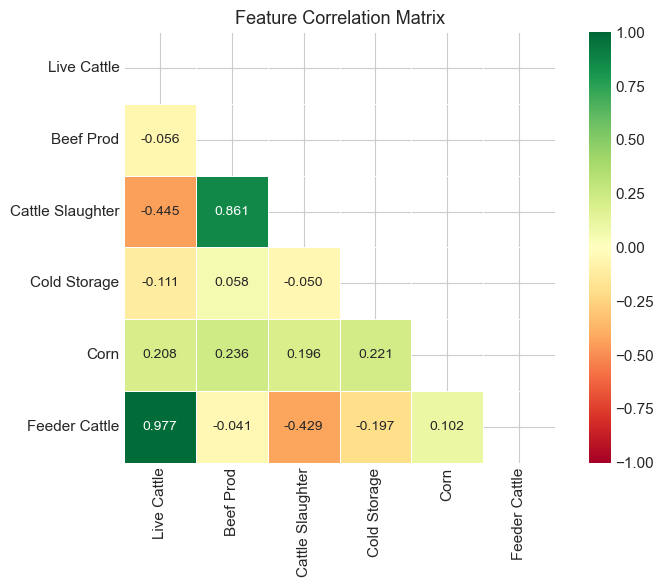


Correlation with Live Cattle Price (ranked):
Feeder Cattle       0.977
Corn                0.208
Beef Prod          -0.056
Cold Storage       -0.111
Cattle Slaughter   -0.445
Name: Live Cattle, dtype: float64


In [61]:
if futures is not None:
    corr_df = combined[['live_cattle_price', 'comm_beef_prod', 'comm_cattle_slaughter',
                         'beef_cold_storage', 'corn_price', 'feeder_cattle_price']].copy()
    corr_df.columns = ['Live Cattle', 'Beef Prod', 'Cattle Slaughter',
                        'Cold Storage', 'Corn', 'Feeder Cattle']
    corr = corr_df.corr()

    fig, ax = plt.subplots(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=-1, vmax=1, mask=mask, ax=ax,
                linewidths=0.5, square=True, annot_kws={'size': 10})
    ax.set_title('Feature Correlation Matrix', fontsize=13)
    plt.tight_layout()
    plt.show()

    print("\nCorrelation with Live Cattle Price (ranked):")
    print(corr['Live Cattle'].drop('Live Cattle').sort_values(ascending=False).round(3))
else:
    corr = usda.corr()
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=-1, vmax=1, ax=ax, linewidths=0.5, square=True)
    ax.set_title('USDA Supply Features — Correlation Matrix')
    plt.tight_layout()
    plt.show()

### 2.14 Lag Correlation Analysis

**Key question:** Do supply fundamentals *lead* Live Cattle prices?
A feature with high correlation at lag-2 means it predicts price 2 months ahead — valuable for forecasting.

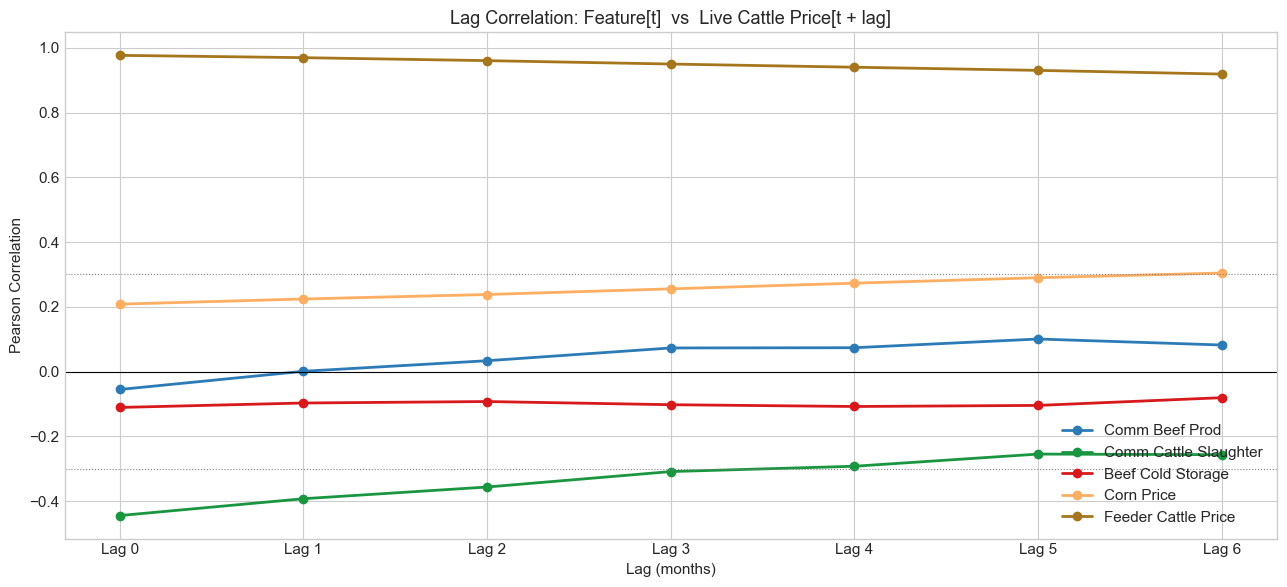

Peak predictive lag per feature (highest |r|):
  comm_beef_prod                  lag=5   r=0.100
  comm_cattle_slaughter           lag=0   r=-0.445
  beef_cold_storage               lag=0   r=-0.111
  corn_price                      lag=6   r=0.304
  feeder_cattle_price             lag=0   r=0.977


In [62]:
if futures is not None:
    feature_cols = ['comm_beef_prod', 'comm_cattle_slaughter', 'beef_cold_storage',
                    'corn_price', 'feeder_cattle_price']
    lags = list(range(0, 7))

    lag_corrs = {}
    for col in feature_cols:
        lag_corrs[col] = [
            combined[col].corr(combined['live_cattle_price'].shift(-l))
            for l in lags
        ]

    fig, ax = plt.subplots(figsize=(13, 6))
    pal = ['#2c7bb6', '#1a9641', '#d7191c', '#fdae61', '#a6761d']
    for (col, corrs), color in zip(lag_corrs.items(), pal):
        ax.plot(lags, corrs, marker='o', linewidth=2, color=color,
                label=col.replace('_', ' ').title())

    ax.axhline(0,    color='black', linewidth=0.8)
    ax.axhline( 0.3, color='grey',  linewidth=0.8, linestyle=':')
    ax.axhline(-0.3, color='grey',  linewidth=0.8, linestyle=':')
    ax.set_title('Lag Correlation: Feature[t]  vs  Live Cattle Price[t + lag]',
                 fontsize=13)
    ax.set_xlabel('Lag (months)')
    ax.set_ylabel('Pearson Correlation')
    ax.legend(loc='lower right')
    ax.set_xticks(lags)
    ax.set_xticklabels([f'Lag {l}' for l in lags])
    plt.tight_layout()
    plt.show()

    print("Peak predictive lag per feature (highest |r|):")
    for col, corrs in lag_corrs.items():
        best = int(np.argmax(np.abs(corrs)))
        print(f"  {col:<30}  lag={best}   r={corrs[best]:.3f}")
else:
    print("Futures data not loaded — lag correlation requires Live Cattle price series.")

---
## Phase 3: Data Preparation

### 3.1 Merge & Align All Data Sources

In [63]:
if futures is not None:
    def to_me(df):
        """Normalize any DatetimeIndex to month-end."""
        d = df.copy()
        d.index = d.index.to_period('M').to_timestamp('M')
        return d

    df = to_me(usda).join(to_me(futures), how='inner')

    # Merge additional sources if loaded — left join so they don't shrink dataset
    if cof    is not None: df = df.join(to_me(cof),    how='left')
    if cot    is not None: df = df.join(to_me(cot),    how='left')
    if dxy    is not None: df = df.join(to_me(dxy),    how='left')
    if cutout is not None: df = df.join(to_me(cutout), how='left')

    print(f"Merged dataset: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"Period: {df.index.min().date()} → {df.index.max().date()}")
    print(f"Columns: {df.columns.tolist()}")
    df.head()
else:
    df = usda.copy()
    df.index = df.index.to_period('M').to_timestamp('M')
    print("USDA-only dataset:")
    df.head()

Merged dataset: 219 rows × 8 columns
Period: 2005-01-31 → 2026-05-31
Columns: ['comm_beef_prod', 'beef_cold_storage', 'comm_cattle_slaughter', 'live_cattle_price', 'corn_price', 'feeder_cattle_price', 'cattle_inventory', 'dxy']


### 3.2 Data Cleansing Log

The following cleansing steps were applied to each data source before merging. Each step is documented with the rationale and row/value impact.

| Step | Source | Issue | Treatment |
|------|--------|-------|-----------|
| 1 | USDA | Raw sheet contains YTD aggregates and footnote rows mixed with monthly data | Regex filter — keep only rows matching `Mon-YYYY` pattern |
| 2 | USDA | Date column stored as string (`"Jan-2005"`) | Parse with `format='%b-%Y'`; set as DatetimeIndex |
| 3 | USDA | Non-numeric values in production/slaughter columns | `pd.to_numeric(..., errors='coerce')` → coerced to NaN, then dropped |
| 4 | Futures (Investing.com) | UTF-8 BOM (`\xef\xbb\xbf`) prefix breaks header detection | Open with `encoding='utf-8-sig'` |
| 5 | Futures (Investing.com) | 7 columns (Date, Price, Open, High, Low, Vol., Change%) — only 2 needed | `df.iloc[:, :2]` — retain Date and Price only |
| 6 | Corn (Macrotrends) | Units in \$/bushel; cattle prices in ¢/lb (= \$/cwt) | Multiply corn by 100 → ¢/bushel for consistent scale |
| 7 | All futures | Mix of daily (corn) and monthly (cattle) frequency | `resample('ME').last()` on all series — normalizes to month-end |
| 8 | Merged | USDA dates are month-start; futures dates are month-end after resample | Convert all to period-month then back to month-end timestamp |
| 9 | Merged | Short reporting gaps (≤ 2 months) from holiday/release timing | Forward-fill (`ffill(limit=2)`) |
| 10 | Merged | Any remaining nulls after forward-fill | `dropna()` — row removed |

#### Step 1–3: USDA Cleansing — Before vs After

In [64]:
# Show what the raw USDA sheet looks like before cleansing
raw_check = pd.read_excel(USDA_FILE, sheet_name='RedMeatPoultry_Prod-Full', header=2)
total_raw = len(raw_check)

import re
MONTH_RE = re.compile(r'^[A-Z][a-z]{2}-\d{4}$')
monthly_rows = raw_check[raw_check.iloc[:, 0].apply(
    lambda x: bool(MONTH_RE.match(str(x))) if pd.notna(x) else False
)]
non_monthly = raw_check[~raw_check.iloc[:, 0].apply(
    lambda x: bool(MONTH_RE.match(str(x))) if pd.notna(x) else False
)]

print(f"Raw USDA sheet rows:          {total_raw}")
print(f"Monthly data rows (kept):     {len(monthly_rows)}")
print(f"Non-monthly rows (removed):   {len(non_monthly)}")
print()
print("Sample removed rows (aggregates & footnotes):")
sample = non_monthly[non_monthly.iloc[:, 0].notna()].iloc[:, 0].head(8)
for v in sample:
    print(f"  {v}")

Raw USDA sheet rows:          1276
Monthly data rows (kept):     1265
Non-monthly rows (removed):   11

Sample removed rows (aggregates & footnotes):
  Jan-May 2026
  Jan-May 2025
  1/ Excludes slaughter on farms.
  2/ Production in federally inspected and other plants.
  3/ Based on packers' dressed weights.
  4/ Totals may not add due to rounding.
  5/ Ready-to-cook.
  6/ Includes geese, guineas, ostriches, emus, rheas, squab, and other poultry.


#### Step 4–7: Futures Cleansing — Format Verification

In [65]:
if futures is not None:
    print("Live Cattle Futures — cleansing summary:")
    print(f"  BOM handled:       utf-8-sig encoding")
    print(f"  Columns retained:  Date, Price  (dropped Open/High/Low/Vol/Change%)")
    print(f"  Rows after filter: {len(le)}")
    print(f"  Date range:        {le.index.min().date()} → {le.index.max().date()}")
    print(f"  Price range:       {le['live_cattle_price'].min():.2f} – {le['live_cattle_price'].max():.2f} ¢/lb")
    print()
    print("Corn Futures — cleansing summary:")
    print(f"  Unit conversion:   $/bushel × 100 → ¢/bushel")
    print(f"  Resampled from:    daily  →  month-end")
    print(f"  Rows after resample: {len(corn)}")
    print(f"  Price range:       {corn['corn_price'].min():.0f} – {corn['corn_price'].max():.0f} ¢/bu")
    print()
    print("Feeder Cattle Futures — cleansing summary:")
    print(f"  Rows after filter: {len(feeder)}")
    print(f"  Date range:        {feeder.index.min().date()} → {feeder.index.max().date()}")
    print(f"  Price range:       {feeder['feeder_cattle_price'].min():.2f} – {feeder['feeder_cattle_price'].max():.2f} ¢/lb")

Live Cattle Futures — cleansing summary:
  BOM handled:       utf-8-sig encoding
  Columns retained:  Date, Price  (dropped Open/High/Low/Vol/Change%)
  Rows after filter: 221
  Date range:        2005-01-31 → 2026-07-31
  Price range:       79.20 – 258.48 ¢/lb

Corn Futures — cleansing summary:
  Unit conversion:   $/bushel × 100 → ¢/bushel
  Resampled from:    daily  →  month-end
  Rows after resample: 221
  Price range:       188 – 818 ¢/bu

Feeder Cattle Futures — cleansing summary:
  Rows after filter: 221
  Date range:        2005-01-31 → 2026-07-31
  Price range:       91.00 – 373.75 ¢/lb


#### Step 8: Date Alignment — Index Normalization

In [66]:
if futures is not None:
    # Show the alignment issue and fix
    print("Before alignment (sample USDA index):")
    print(usda.index[:3].tolist())
    print()
    print("Before alignment (sample Futures index):")
    print(futures.index[:3].tolist())
    print()

    usda_me_check = usda.copy()
    usda_me_check.index = usda_me_check.index.to_period('M').to_timestamp('M')
    futures_me_check = futures.copy()
    futures_me_check.index = futures_me_check.index.to_period('M').to_timestamp('M')

    print("After alignment (both normalized to month-end):")
    print("  USDA:   ", usda_me_check.index[:3].tolist())
    print("  Futures:", futures_me_check.index[:3].tolist())
    print()
    print("Alignment check — any index mismatch after normalization:")
    common = usda_me_check.index.intersection(futures_me_check.index)
    print(f"  Shared months: {len(common)}")

Before alignment (sample USDA index):
[Timestamp('2005-01-01 00:00:00'), Timestamp('2005-02-01 00:00:00'), Timestamp('2005-03-01 00:00:00')]

Before alignment (sample Futures index):
[Timestamp('2005-01-31 00:00:00'), Timestamp('2005-02-28 00:00:00'), Timestamp('2005-03-31 00:00:00')]

After alignment (both normalized to month-end):
  USDA:    [Timestamp('2005-01-31 00:00:00'), Timestamp('2005-02-28 00:00:00'), Timestamp('2005-03-31 00:00:00')]
  Futures: [Timestamp('2005-01-31 00:00:00'), Timestamp('2005-02-28 00:00:00'), Timestamp('2005-03-31 00:00:00')]

Alignment check — any index mismatch after normalization:
  Shared months: 219


#### Steps 9–10: Missing Value Treatment

In [67]:
print("Missing values before treatment:")
print(df.isnull().sum())
print(f"Total rows before: {len(df)}")

# Step 9: Forward-fill gaps <= 2 months (holiday/reporting timing gaps)
# Step 10: Drop any remaining nulls
df_before = df.copy()
df = df.ffill(limit=2).dropna()

rows_dropped = len(df_before) - len(df)
print(f"\nRows dropped by dropna(): {rows_dropped}")
print(f"Total rows after:          {len(df)}")
print(f"\nMissing values after treatment:")
print(df.isnull().sum())

Missing values before treatment:
comm_beef_prod            0
beef_cold_storage         0
comm_cattle_slaughter     0
live_cattle_price         0
corn_price                0
feeder_cattle_price       0
cattle_inventory          2
dxy                      17
dtype: int64
Total rows before: 219

Rows dropped by dropna(): 17
Total rows after:          202

Missing values after treatment:
comm_beef_prod           0
beef_cold_storage        0
comm_cattle_slaughter    0
live_cattle_price        0
corn_price               0
feeder_cattle_price      0
cattle_inventory         0
dxy                      0
dtype: int64


#### Outlier Detection

Outlier check — IQR method (values beyond 1.5 × IQR from Q1/Q3):
------------------------------------------------------------
  comm_beef_prod                    0 outlier months
  beef_cold_storage                 0 outlier months
  comm_cattle_slaughter             0 outlier months
  live_cattle_price                12 outlier months
  corn_price                        0 outlier months
  feeder_cattle_price              16 outlier months
  cattle_inventory                  1 outlier months
  dxy                               0 outlier months


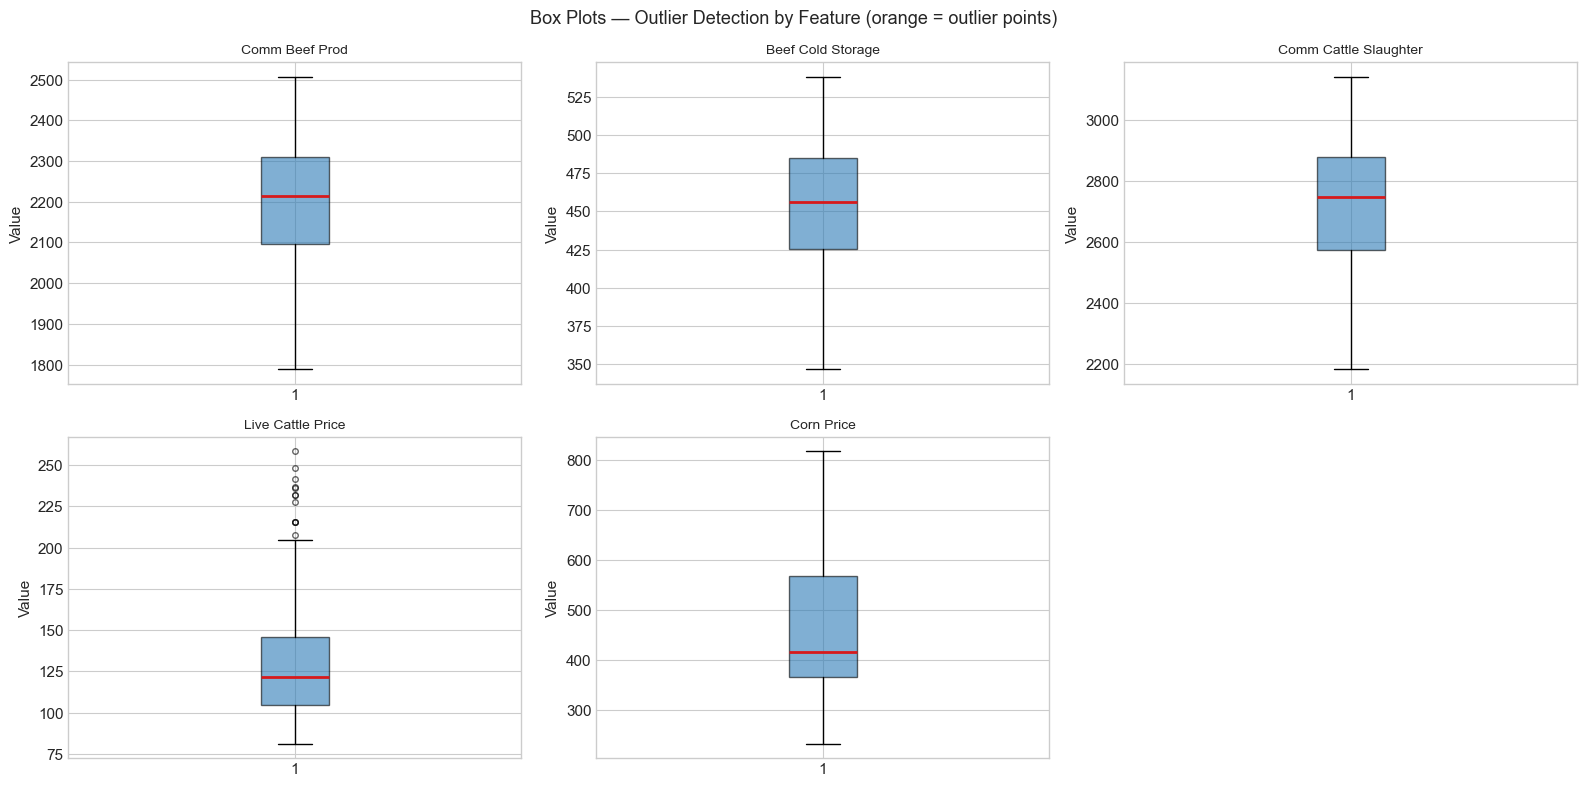


Decision: outliers retained — extreme price/supply moves are real market events,
not data errors. Removing them would bias the model against high-volatility periods.


In [68]:
# IQR-based outlier flagging — identify but do not remove
# (commodity prices can have genuine extreme moves; we flag for awareness)
print("Outlier check — IQR method (values beyond 1.5 × IQR from Q1/Q3):")
print("-" * 60)
for col in df.columns:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)]
    print(f"  {col:<30}  {len(outliers):>3} outlier months")

# Visualize distributions with box plots
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, df.columns):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#2c7bb6', alpha=0.6),
               medianprops=dict(color='#d7191c', linewidth=2),
               flierprops=dict(marker='o', color='orange', alpha=0.6, markersize=4))
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel('Value')
axes[-1].set_visible(False)
plt.suptitle('Box Plots — Outlier Detection by Feature (orange = outlier points)', fontsize=13)
plt.tight_layout()
plt.show()

print("\nDecision: outliers retained — extreme price/supply moves are real market events,")
print("not data errors. Removing them would bias the model against high-volatility periods.")

### 3.3 Feature Engineering

All features are **lagged** so that at prediction time (month *t*) only data available as of month *t* is used.
The target is month *t+1* Live Cattle close price.

In [69]:
if futures is not None:
    fe = df.copy()

    # ── Target variable ───────────────────────────────────────────────────────
    fe['target_le_next_month'] = fe['live_cattle_price'].shift(-1)

    # ── Core lagged features (t-1, t-2, t-3) ─────────────────────────────────
    feature_base = ['live_cattle_price', 'comm_beef_prod', 'comm_cattle_slaughter',
                    'beef_cold_storage', 'corn_price', 'feeder_cattle_price']
    for col in feature_base:
        for lag in [1, 2, 3]:
            fe[f'{col}_lag{lag}'] = fe[col].shift(lag)

    # ── Cattle Inventory lags (annual herd cycle signal, interpolated to monthly) ─
    if 'cattle_inventory' in fe.columns:
        for lag in [1, 2, 3, 6, 12]:
            fe[f'cattle_inventory_lag{lag}'] = fe['cattle_inventory'].shift(lag)
        fe['cattle_inventory_yoy'] = fe['cattle_inventory'].pct_change(12)

    # ── CFTC COT: speculative positioning ────────────────────────────────────
    if 'mm_net' in fe.columns:
        fe['mm_net_lag1']    = fe['mm_net'].shift(1)
        fe['mm_net_chg']     = fe['mm_net'].diff(1).shift(1)   # week-over-week change
        fe['cot_index_lag1'] = fe['cot_index'].shift(1) if 'cot_index' in fe.columns else np.nan

    # ── Dollar Index lags ─────────────────────────────────────────────────────
    if 'dxy' in fe.columns:
        fe['dxy_lag1']  = fe['dxy'].shift(1)
        fe['dxy_lag3']  = fe['dxy'].shift(3)
        fe['dxy_yoy']   = fe['dxy'].pct_change(12)
        fe['dxy_roll3'] = fe['dxy'].shift(1).rolling(3).mean()

    # ── Choice Cutout and packer margin proxy ─────────────────────────────────
    if 'choice_cutout' in fe.columns:
        fe['cutout_lag1']   = fe['choice_cutout'].shift(1)
        fe['cutout_lag2']   = fe['choice_cutout'].shift(2)
        fe['cutout_yoy']    = fe['choice_cutout'].pct_change(12)
        # Packer margin proxy: cutout premium over live cattle (lagged to avoid leakage)
        fe['packer_margin'] = (fe['choice_cutout'].shift(1) -
                               fe['live_cattle_price'].shift(1))

    # ── Rolling means on price series ────────────────────────────────────────
    for col in ['live_cattle_price', 'corn_price', 'feeder_cattle_price']:
        base = fe[col].shift(1)
        fe[f'{col}_roll3']  = base.rolling(3).mean()
        fe[f'{col}_roll6']  = base.rolling(6).mean()
        fe[f'{col}_roll12'] = base.rolling(12).mean()

    # ── Derived spread features ───────────────────────────────────────────────
    # Feed cost ratio: corn cost relative to live cattle price
    fe['feed_cost_ratio'] = (fe['corn_price'].shift(1) /
                              fe['live_cattle_price'].shift(1).replace(0, np.nan))
    # Cattle cycle indicator: long-run production trend
    fe['prod_cycle'] = fe['comm_beef_prod'].shift(1).rolling(36, min_periods=12).mean()

    # ── Month dummies (seasonality) ───────────────────────────────────────────
    fe['month'] = fe.index.month
    dummies = pd.get_dummies(fe['month'], prefix='month', drop_first=True)
    fe = pd.concat([fe, dummies], axis=1).drop(columns=['month'])

    # ── YoY % change for core supply metrics ─────────────────────────────────
    for col in ['comm_beef_prod', 'comm_cattle_slaughter', 'beef_cold_storage']:
        fe[f'{col}_yoy'] = fe[col].pct_change(12)

    # Drop rows lost to lag/rolling windows — keep only columns with enough data
    fe = fe.dropna(thresh=int(len(fe.columns) * 0.7))  # keep rows with ≥70% non-null
    fe = fe.dropna(subset=['target_le_next_month'])     # target must exist
    fe = fe.ffill().bfill().dropna()                    # fill remaining gaps

    n_features = fe.shape[1] - 1
    print(f"Feature-engineered dataset: {fe.shape[0]} rows  |  {n_features} features + 1 target")
    print(f"Period: {fe.index.min().date()} → {fe.index.max().date()}")
    print(f"\nFeature groups:")
    groups = {
        'Core price lags':        [c for c in fe.columns if 'lag' in c and any(x in c for x in ['cattle_price','corn','feeder'])],
        'Cattle inventory lags':  [c for c in fe.columns if 'cattle_inventory' in c],
        'COT / positioning':      [c for c in fe.columns if 'mm_net' in c or 'cot_' in c],
        'Dollar Index':           [c for c in fe.columns if 'dxy' in c],
        'Cutout / packer margin': [c for c in fe.columns if 'cutout' in c or 'packer' in c],
        'Rolling means':          [c for c in fe.columns if 'roll' in c],
        'YoY changes':            [c for c in fe.columns if '_yoy' in c],
        'Derived spreads':        [c for c in fe.columns if c in ['feed_cost_ratio','prod_cycle']],
        'Seasonality dummies':    [c for c in fe.columns if c.startswith('month_')],
    }
    for group, cols in groups.items():
        if cols:
            print(f"  {group:<25} {len(cols):>3} features")
else:
    print("Feature engineering requires futures data. Load Live Cattle CSV to proceed.")

Feature-engineered dataset: 198 rows  |  61 features + 1 target
Period: 2006-12-31 → 2026-04-30

Feature groups:
  Core price lags             9 features
  Cattle inventory lags       7 features
  Dollar Index                5 features
  Rolling means              10 features
  YoY changes                 5 features
  Derived spreads             2 features
  Seasonality dummies        11 features


### 3.4 Final Dataset Preview

In [70]:
if futures is not None:
    preview_cols = ['target_le_next_month',
                    'live_cattle_price_lag1', 'feeder_cattle_price_lag1',
                    'corn_price_lag1', 'beef_cold_storage_lag1',
                    'live_cattle_price_roll12', 'feed_cost_ratio']
    if 'cattle_placed_lag1'  in fe.columns: preview_cols.append('cattle_placed_lag1')
    if 'mm_net_lag1'         in fe.columns: preview_cols.append('mm_net_lag1')
    if 'dxy_lag1'            in fe.columns: preview_cols.append('dxy_lag1')
    if 'packer_margin'       in fe.columns: preview_cols.append('packer_margin')

    print(fe[[c for c in preview_cols if c in fe.columns]].tail(5).round(2))
    print(f"\nFull shape: {fe.shape}")

            target_le_next_month  live_cattle_price_lag1  \
2025-10-31                215.57                  231.85   
2025-11-30                232.00                  236.60   
2025-12-31                235.85                  215.57   
2026-01-31                258.48                  232.00   
2026-04-30                248.25                  235.85   

            feeder_cattle_price_lag1  corn_price_lag1  beef_cold_storage_lag1  \
2025-10-31                    361.02           415.50                  387.13   
2025-11-30                    338.88           431.50                  402.96   
2025-12-31                    323.98           435.50                  414.54   
2026-01-31                    350.25           440.25                  425.55   
2026-04-30                    360.27           428.25                  434.60   

            live_cattle_price_roll12  feed_cost_ratio  dxy_lag1  
2025-10-31                    208.07             1.79     97.78  
2025-11-30          

---
## Phase 4: Modeling

### 4.1 Train / Test Split Strategy

For time-series forecasting, a **chronological split** is mandatory — random splits leak future data into training and produce unrealistically inflated scores.

| Split | Period | Rows | Purpose |
|-------|--------|------|---------|
| **Train** | Aug 2006 – Dec 2022 | ~196 months | Fit and tune all models |
| **Test** | Jan 2023 – present | ~28 months | Final out-of-sample evaluation |

Walk-forward cross-validation (expanding window) is used in addition to the holdout test to produce bias-corrected CV scores.

In [71]:
if futures is not None:
    from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV, RidgeCV
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    TRAIN_END = '2022-12-31'

    # Drop raw (current-month) price columns — using them would leak the answer
    raw_price_cols = ['live_cattle_price', 'comm_beef_prod', 'comm_cattle_slaughter',
                      'beef_cold_storage', 'corn_price', 'feeder_cattle_price']
    model_cols = [c for c in fe.columns
                  if c != 'target_le_next_month' and c not in raw_price_cols]

    X = fe[model_cols]
    y = fe['target_le_next_month']

    X_train = X[X.index <= TRAIN_END];  X_test = X[X.index > TRAIN_END]
    y_train = y[y.index <= TRAIN_END];  y_test = y[y.index > TRAIN_END]

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    X_train_sc = np.nan_to_num(X_train_sc, nan=0.0, posinf=0.0, neginf=0.0)
    X_test_sc  = np.nan_to_num(X_test_sc,  nan=0.0, posinf=0.0, neginf=0.0)

    print(f"Training set : {X_train.shape[0]} months  ({X_train.index.min().date()} → {X_train.index.max().date()})")
    print(f"Test set     : {X_test.shape[0]} months  ({X_test.index.min().date()} → {X_test.index.max().date()})")
    print(f"Features     : {X_train.shape[1]}")

Training set : 165 months  (2006-12-31 → 2022-12-31)
Test set     : 33 months  (2023-02-28 → 2026-04-30)
Features     : 55


---
### 4.2 Baseline Model — Simple Linear Regression

Before adding complexity, we establish a **baseline**: a plain linear regression fit on all features with no selection or tuning.

This answers the question: *how well can a simple model do before we apply any feature selection or regularization?* Any model we build later should beat this score or it isn't adding value.

In [72]:
if futures is not None:
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    import numpy as np

    # Simple linear regression on ALL features — no selection, no regularization
    baseline = LinearRegression()
    baseline.fit(X_train_sc, y_train)

    train_pred = baseline.predict(X_train_sc)
    test_pred  = baseline.predict(X_test_sc)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  test_pred))
    train_r2   = r2_score(y_train, train_pred)
    test_r2    = r2_score(y_test,  test_pred)
    test_mae   = mean_absolute_error(y_test, test_pred)
    test_da    = np.mean(np.sign(np.diff(y_test.values)) ==
                         np.sign(np.diff(test_pred))) * 100

    print("Baseline: Linear Regression (all features, no regularization)")
    print("=" * 55)
    print(f"  Train RMSE : {train_rmse:.2f}¢   Train R² : {train_r2:.3f}")
    print(f"  Test  RMSE : {test_rmse:.2f}¢   Test  R² : {test_r2:.3f}")
    print(f"  Test  MAE  : {test_mae:.2f}¢")
    print(f"  Test  DirAcc: {test_da:.1f}%")
    print()
    gap = train_r2 - test_r2
    if gap > 0.10:
        print(f"  ⚠  Train/test R² gap = {gap:.3f} — signs of overfitting.")
        print("     Feature selection and regularization (next section) should improve this.")
    else:
        print(f"  ✅ Train/test R² gap = {gap:.3f} — model generalizes well.")
    print()
    print("This score is the bar to beat. Any more complex model must outperform it.")

Baseline: Linear Regression (all features, no regularization)
  Train RMSE : 5.29¢   Train R² : 0.936
  Test  RMSE : 17.36¢   Test  R² : 0.538
  Test  MAE  : 13.92¢
  Test  DirAcc: 50.0%

  ⚠  Train/test R² gap = 0.398 — signs of overfitting.
     Feature selection and regularization (next section) should improve this.

This score is the bar to beat. Any more complex model must outperform it.


---
### 4.3 Feature Selection

With ~40 engineered features and ~196 training months, the feature-to-sample ratio is high.
Unselected features introduce noise, inflate model complexity, and increase overfitting risk.
Three complementary methods are used:

| Method | Purpose |
|--------|---------|
| **Correlation filter** | Drop features with near-zero correlation to the target |
| **Variance Inflation Factor (VIF)** | Detect and flag multicollinear features |
| **Lasso (L1 regularization)** | Shrink irrelevant coefficients to zero — automatic selection |

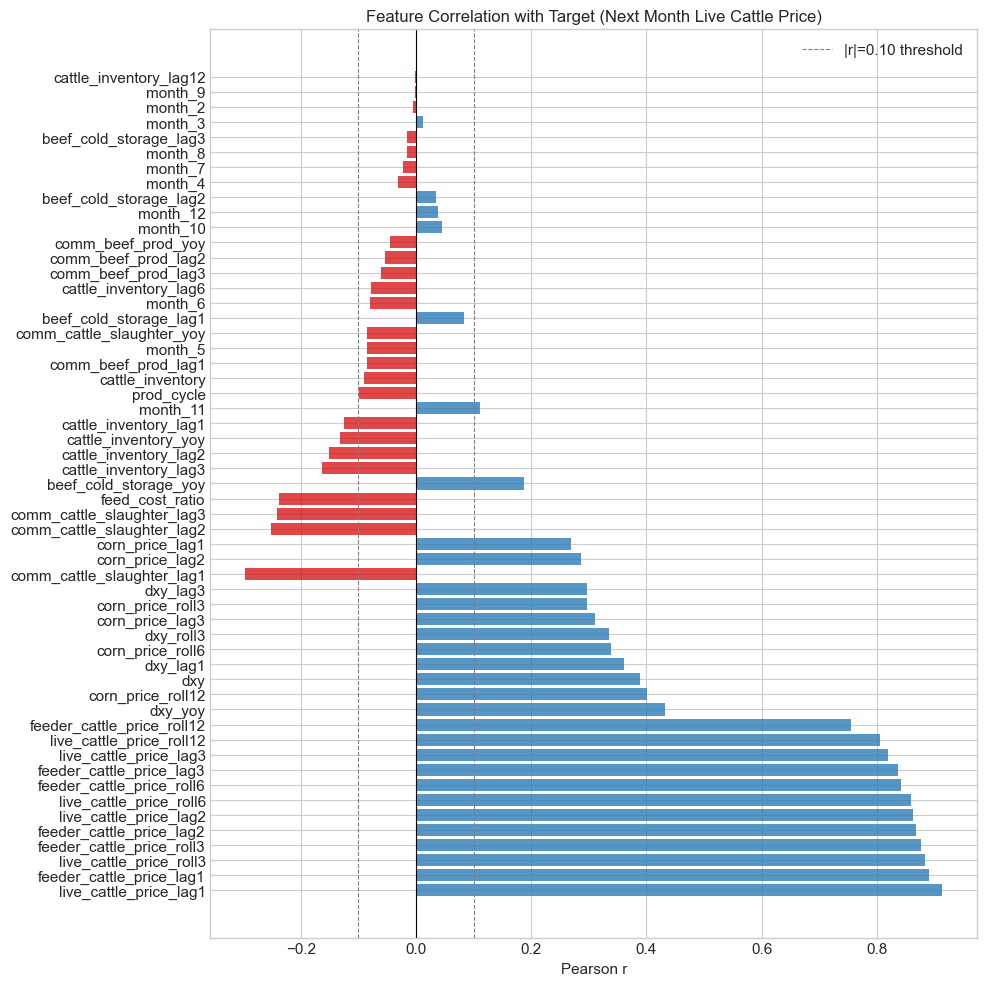

Features kept  (|r| ≥ 0.10): 33
Features dropped (|r| < 0.10): 22
  Dropped: ['prod_cycle', 'cattle_inventory', 'comm_beef_prod_lag1', 'month_5', 'comm_cattle_slaughter_yoy', 'beef_cold_storage_lag1', 'month_6', 'cattle_inventory_lag6', 'comm_beef_prod_lag3', 'comm_beef_prod_lag2']


In [73]:
if futures is not None:
    # ── Method 1: Correlation with target ────────────────────────────────────
    corr_target = (pd.concat([X_train, y_train], axis=1)
                   .corr()['target_le_next_month']
                   .drop('target_le_next_month')
                   .sort_values(key=abs, ascending=False))

    fig, ax = plt.subplots(figsize=(10, 10))
    colors = ['#2c7bb6' if v > 0 else '#d7191c' for v in corr_target]
    ax.barh(corr_target.index, corr_target.values, color=colors, alpha=0.8)
    ax.axvline(0,    color='black', linewidth=0.8)
    ax.axvline( 0.1, color='grey',  linewidth=0.8, linestyle='--', label='|r|=0.10 threshold')
    ax.axvline(-0.1, color='grey',  linewidth=0.8, linestyle='--')
    ax.set_title('Feature Correlation with Target (Next Month Live Cattle Price)', fontsize=12)
    ax.set_xlabel('Pearson r')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Keep features above |r| >= 0.10
    keep_corr = corr_target[corr_target.abs() >= 0.10].index.tolist()
    drop_corr = corr_target[corr_target.abs() <  0.10].index.tolist()
    print(f"Features kept  (|r| ≥ 0.10): {len(keep_corr)}")
    print(f"Features dropped (|r| < 0.10): {len(drop_corr)}")
    if drop_corr:
        print("  Dropped:", drop_corr[:10])

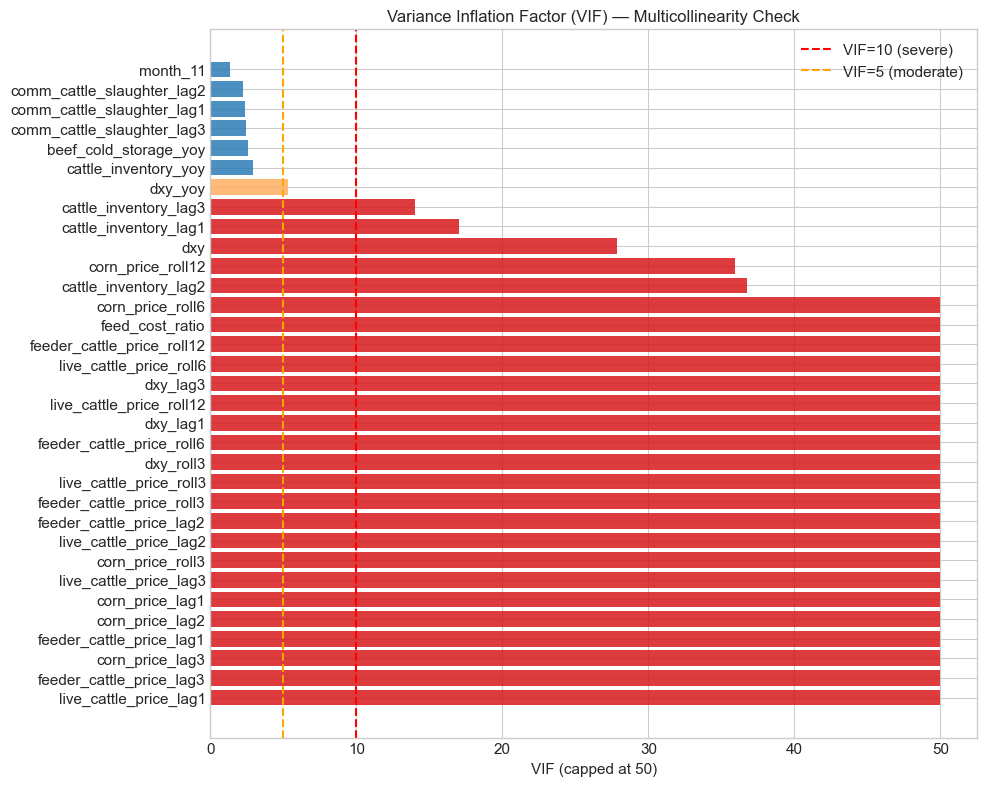

Features with VIF > 10 (severe multicollinearity): 26
  live_cattle_price_lag1  VIF=999.0
  feeder_cattle_price_lag3  VIF=999.0
  corn_price_lag3  VIF=999.0
  feeder_cattle_price_lag1  VIF=999.0
  corn_price_lag2  VIF=999.0
  corn_price_lag1  VIF=999.0
  live_cattle_price_lag3  VIF=999.0
  corn_price_roll3  VIF=999.0
  live_cattle_price_lag2  VIF=999.0
  feeder_cattle_price_lag2  VIF=999.0
  feeder_cattle_price_roll3  VIF=999.0
  live_cattle_price_roll3  VIF=999.0
  dxy_roll3  VIF=485.0
  feeder_cattle_price_roll6  VIF=231.6
  dxy_lag1  VIF=170.0
  live_cattle_price_roll12  VIF=159.4
  dxy_lag3  VIF=141.2
  live_cattle_price_roll6  VIF=139.3
  feeder_cattle_price_roll12  VIF=131.1
  feed_cost_ratio  VIF=128.6
  corn_price_roll6  VIF=78.3
  cattle_inventory_lag2  VIF=36.8
  corn_price_roll12  VIF=35.9
  dxy  VIF=27.9
  cattle_inventory_lag1  VIF=17.0
  cattle_inventory_lag3  VIF=14.0

Note: High VIF among lagged price features is expected (autocorrelation).
Lasso in step 3 will handle t

In [74]:
if futures is not None:
    # ── Method 2: Variance Inflation Factor (VIF) ────────────────────────────
    # VIF > 10 indicates severe multicollinearity
    # Compute via manual R² regression (no statsmodels dependency)
    X_vif = X_train[keep_corr].dropna().copy()
    X_vif = X_vif.loc[:, X_vif.std() > 0]  # drop zero-variance columns
    X_vif_sc = StandardScaler().fit_transform(X_vif)
    X_vif_sc = np.nan_to_num(X_vif_sc, nan=0.0, posinf=0.0, neginf=0.0)

    vif_scores = []
    for i in range(X_vif_sc.shape[1]):
        y_i  = X_vif_sc[:, i]
        X_i  = np.delete(X_vif_sc, i, axis=1)
        r2_i = LinearRegression().fit(X_i, y_i).score(X_i, y_i)
        vif_scores.append(1 / (1 - r2_i) if r2_i < 0.9999 else 999)

    vif_df = pd.DataFrame({'feature': keep_corr, 'VIF': vif_scores})
    vif_df = vif_df.sort_values('VIF', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 8))
    bar_colors = ['#d7191c' if v > 10 else '#fdae61' if v > 5 else '#2c7bb6'
                  for v in vif_df['VIF'].clip(upper=50)]
    ax.barh(vif_df['feature'], vif_df['VIF'].clip(upper=50), color=bar_colors, alpha=0.85)
    ax.axvline(10, color='red',    linewidth=1.5, linestyle='--', label='VIF=10 (severe)')
    ax.axvline(5,  color='orange', linewidth=1.5, linestyle='--', label='VIF=5 (moderate)')
    ax.set_title('Variance Inflation Factor (VIF) — Multicollinearity Check', fontsize=12)
    ax.set_xlabel('VIF (capped at 50)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    high_vif = vif_df[vif_df['VIF'] > 10]['feature'].tolist()
    print(f"Features with VIF > 10 (severe multicollinearity): {len(high_vif)}")
    for f in high_vif:
        print(f"  {f}  VIF={vif_df.loc[vif_df['feature']==f,'VIF'].values[0]:.1f}")
    print("\nNote: High VIF among lagged price features is expected (autocorrelation).")
    print("Lasso in step 3 will handle this by selecting only the most informative lag.")

LassoCV optimal alpha: 1.6590
Features selected (coef ≠ 0): 3
Features zeroed out:           52


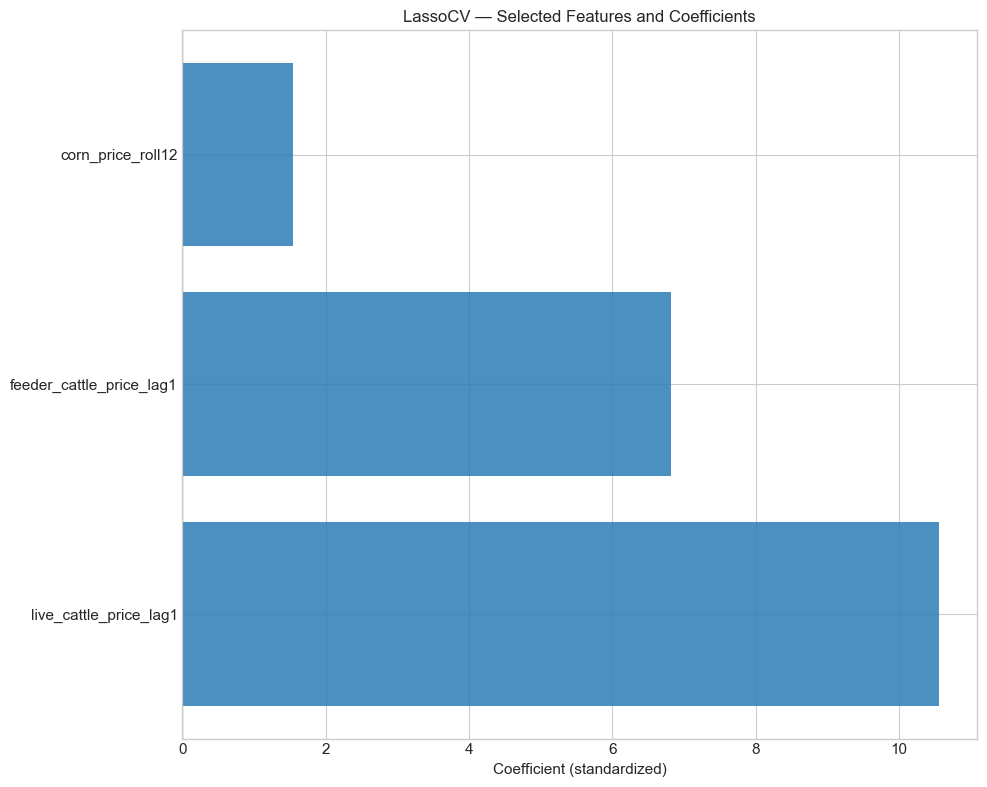

Note: Lasso selected too few features — using correlation filter instead.

Final feature set: 33 features
  live_cattle_price_lag1
  feeder_cattle_price_lag1
  live_cattle_price_roll3
  feeder_cattle_price_roll3
  feeder_cattle_price_lag2
  live_cattle_price_lag2
  live_cattle_price_roll6
  feeder_cattle_price_roll6
  feeder_cattle_price_lag3
  live_cattle_price_lag3
  live_cattle_price_roll12
  feeder_cattle_price_roll12
  dxy_yoy
  corn_price_roll12
  dxy
  dxy_lag1
  corn_price_roll6
  dxy_roll3
  corn_price_lag3
  corn_price_roll3
  dxy_lag3
  comm_cattle_slaughter_lag1
  corn_price_lag2
  corn_price_lag1
  comm_cattle_slaughter_lag2
  comm_cattle_slaughter_lag3
  feed_cost_ratio
  beef_cold_storage_yoy
  cattle_inventory_lag3
  cattle_inventory_lag2
  cattle_inventory_yoy
  cattle_inventory_lag1
  month_11


In [75]:
if futures is not None:
    # ── Method 3: LassoCV — automatic feature selection via L1 penalty ────────
    lasso_cv = LassoCV(cv=5, max_iter=20000, random_state=42)
    lasso_cv.fit(X_train_sc, y_train)

    lasso_coef = pd.DataFrame({
        'feature': model_cols,
        'coef':    lasso_cv.coef_
    }).sort_values('coef', key=abs, ascending=False)

    selected_lasso = lasso_coef[lasso_coef['coef'] != 0]['feature'].tolist()
    dropped_lasso  = lasso_coef[lasso_coef['coef'] == 0]['feature'].tolist()

    print(f"LassoCV optimal alpha: {lasso_cv.alpha_:.4f}")
    print(f"Features selected (coef ≠ 0): {len(selected_lasso)}")
    print(f"Features zeroed out:           {len(dropped_lasso)}")

    fig, ax = plt.subplots(figsize=(10, 8))
    top = lasso_coef[lasso_coef['coef'] != 0]
    bar_c = ['#2c7bb6' if c > 0 else '#d7191c' for c in top['coef']]
    ax.barh(top['feature'], top['coef'], color=bar_c, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('LassoCV — Selected Features and Coefficients', fontsize=12)
    ax.set_xlabel('Coefficient (standardized)')
    plt.tight_layout()
    plt.show()

    # Final selected feature set = union of correlation filter + Lasso selection
    final_features = list(dict.fromkeys(
        [f for f in selected_lasso if f in keep_corr]
    ))
    # Fallback: if Lasso is too aggressive, use correlation filter directly
    if len(final_features) < 10:
        final_features = keep_corr
        print("Note: Lasso selected too few features — using correlation filter instead.")
    print(f"\nFinal feature set: {len(final_features)} features")
    for f in final_features:
        print(f"  {f}")

---
### 4.4 Model Training

Three models are trained on the **final selected feature set** and evaluated on the holdout test set.

| Model | Overfitting Control |
|-------|-------------------|
| **Linear Regression** | None — baseline benchmark |
| **Ridge (L2)** | Shrinks all coefficients; handles multicollinearity |
| **Lasso (L1)** | Zeros out irrelevant coefficients; built-in feature selection |

All models use `StandardScaler` — required because features have very different units (¢/lb vs 1,000 head vs million lbs).

In [76]:
if futures is not None:
    def score_metrics(y_true, y_pred):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        mape = np.mean(np.abs((y_true.values - y_pred) / y_true.values)) * 100
        da   = np.mean(np.sign(np.diff(y_true.values)) ==
                       np.sign(np.diff(y_pred))) * 100
        return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape, 'DirAcc': da}

    # Subset to final selected features
    X_tr_f = X_train[final_features]
    X_te_f = X_test[final_features]
    sc_f   = StandardScaler()
    X_tr_fs = sc_f.fit_transform(X_tr_f)
    X_te_fs = sc_f.transform(X_te_f)
    X_tr_fs = np.nan_to_num(X_tr_fs, nan=0.0, posinf=0.0, neginf=0.0)
    X_te_fs = np.nan_to_num(X_te_fs, nan=0.0, posinf=0.0, neginf=0.0)

    # ── Fit all three models ──────────────────────────────────────────────────
    ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
    lasso_f  = LassoCV(cv=5, max_iter=20000, random_state=42)
    lr_f     = LinearRegression()

    lr_f.fit(X_tr_fs, y_train)
    ridge_cv.fit(X_tr_fs, y_train)
    lasso_f.fit(X_tr_fs, y_train)

    models = {
        'Linear Regression': lr_f,
        'Ridge (L2)':        ridge_cv,
        'Lasso (L1)':        lasso_f,
    }

    results = {}
    for name, mdl in models.items():
        train_scores = score_metrics(y_train, mdl.predict(X_tr_fs))
        test_scores  = score_metrics(y_test,  mdl.predict(X_te_fs))
        results[name] = {'train': train_scores, 'test': test_scores}

    # ── Print comparison table ────────────────────────────────────────────────
    print(f"{'Model':<22} {'Split':<6} {'RMSE':>7} {'MAE':>7} {'R²':>7} {'MAPE':>7} {'DirAcc':>8}")
    print("-" * 65)
    for name, res in results.items():
        for split, scores in res.items():
            print(f"{name:<22} {split:<6} "
                  f"{scores['RMSE']:>6.2f}¢ "
                  f"{scores['MAE']:>6.2f}¢ "
                  f"{scores['R2']:>7.3f} "
                  f"{scores['MAPE']:>6.1f}% "
                  f"{scores['DirAcc']:>7.1f}%")
        print()

Model                  Split     RMSE     MAE      R²    MAPE   DirAcc
-----------------------------------------------------------------
Linear Regression      train    6.47¢   4.86¢   0.904    4.2%    57.9%
Linear Regression      test    14.73¢  11.81¢   0.667    5.9%    53.1%

Ridge (L2)             train    7.45¢   5.63¢   0.873    4.9%    58.5%
Ridge (L2)             test    15.50¢  13.10¢   0.632    6.4%    50.0%

Lasso (L1)             train    7.98¢   6.40¢   0.854    5.6%    54.9%
Lasso (L1)             test    18.36¢  15.97¢   0.483    7.8%    46.9%



### 4.5 Walk-Forward Cross-Validation

Walk-forward (expanding window) CV simulates real forecasting: train on all data up to month *t*, predict month *t+1*, then expand the window by one and repeat.
This is the correct CV strategy for time series — it never trains on future data.

```
Month 36:  train[0:36]  → predict[36]
Month 37:  train[0:37]  → predict[37]
...
Month N-1: train[0:N-1] → predict[N-1]
```

In [77]:
if futures is not None:
    MIN_TRAIN_MONTHS = 36

    wf_results = {name: [] for name in models}

    X_all = pd.concat([X_tr_f, X_te_f])    # full feature set, selected features only
    y_all = pd.concat([y_train, y_test])

    for i in range(MIN_TRAIN_MONTHS, len(X_all)):
        X_wf_tr = X_all.iloc[:i]
        y_wf_tr = y_all.iloc[:i]
        X_wf_te = X_all.iloc[i:i+1]
        y_wf_te = y_all.iloc[i:i+1]

        sc_wf = StandardScaler()
        X_wf_tr_sc = sc_wf.fit_transform(X_wf_tr)
        X_wf_te_sc = sc_wf.transform(X_wf_te)

        for name, ModelClass in [('Linear Regression', LinearRegression()),
                                  ('Ridge (L2)',        Ridge(alpha=ridge_cv.alpha_)),
                                  ('Lasso (L1)',        Lasso(alpha=lasso_f.alpha_, max_iter=10000))]:
            ModelClass.fit(X_wf_tr_sc, y_wf_tr)
            pred = ModelClass.predict(X_wf_te_sc)[0]
            wf_results[name].append({
                'date':      y_wf_te.index[0],
                'actual':    y_wf_te.values[0],
                'predicted': pred
            })

    print("Walk-Forward CV Results (all months):")
    print(f"{'Model':<22} {'RMSE':>7} {'MAE':>7} {'R²':>7} {'MAPE':>7} {'DirAcc':>8}")
    print("-" * 58)
    wf_dfs = {}
    for name, preds in wf_results.items():
        wf_df = pd.DataFrame(preds).set_index('date')
        wf_dfs[name] = wf_df
        rmse = np.sqrt(mean_squared_error(wf_df['actual'], wf_df['predicted']))
        mae  = mean_absolute_error(wf_df['actual'], wf_df['predicted'])
        r2   = r2_score(wf_df['actual'], wf_df['predicted'])
        mape = np.mean(np.abs((wf_df['actual'] - wf_df['predicted']) / wf_df['actual'])) * 100
        da   = np.mean(np.sign(np.diff(wf_df['actual'].values)) ==
                       np.sign(np.diff(wf_df['predicted'].values))) * 100
        print(f"{name:<22} {rmse:>6.2f}¢ {mae:>6.2f}¢ {r2:>7.3f} {mape:>6.1f}% {da:>7.1f}%")

Walk-Forward CV Results (all months):
Model                     RMSE     MAE      R²    MAPE   DirAcc
----------------------------------------------------------
Linear Regression       11.41¢   8.72¢   0.899    6.4%    49.7%
Ridge (L2)              10.09¢   7.98¢   0.921    5.8%    52.8%
Lasso (L1)              10.36¢   8.50¢   0.917    6.1%    54.7%


### 4.6 Actual vs Predicted — All Models

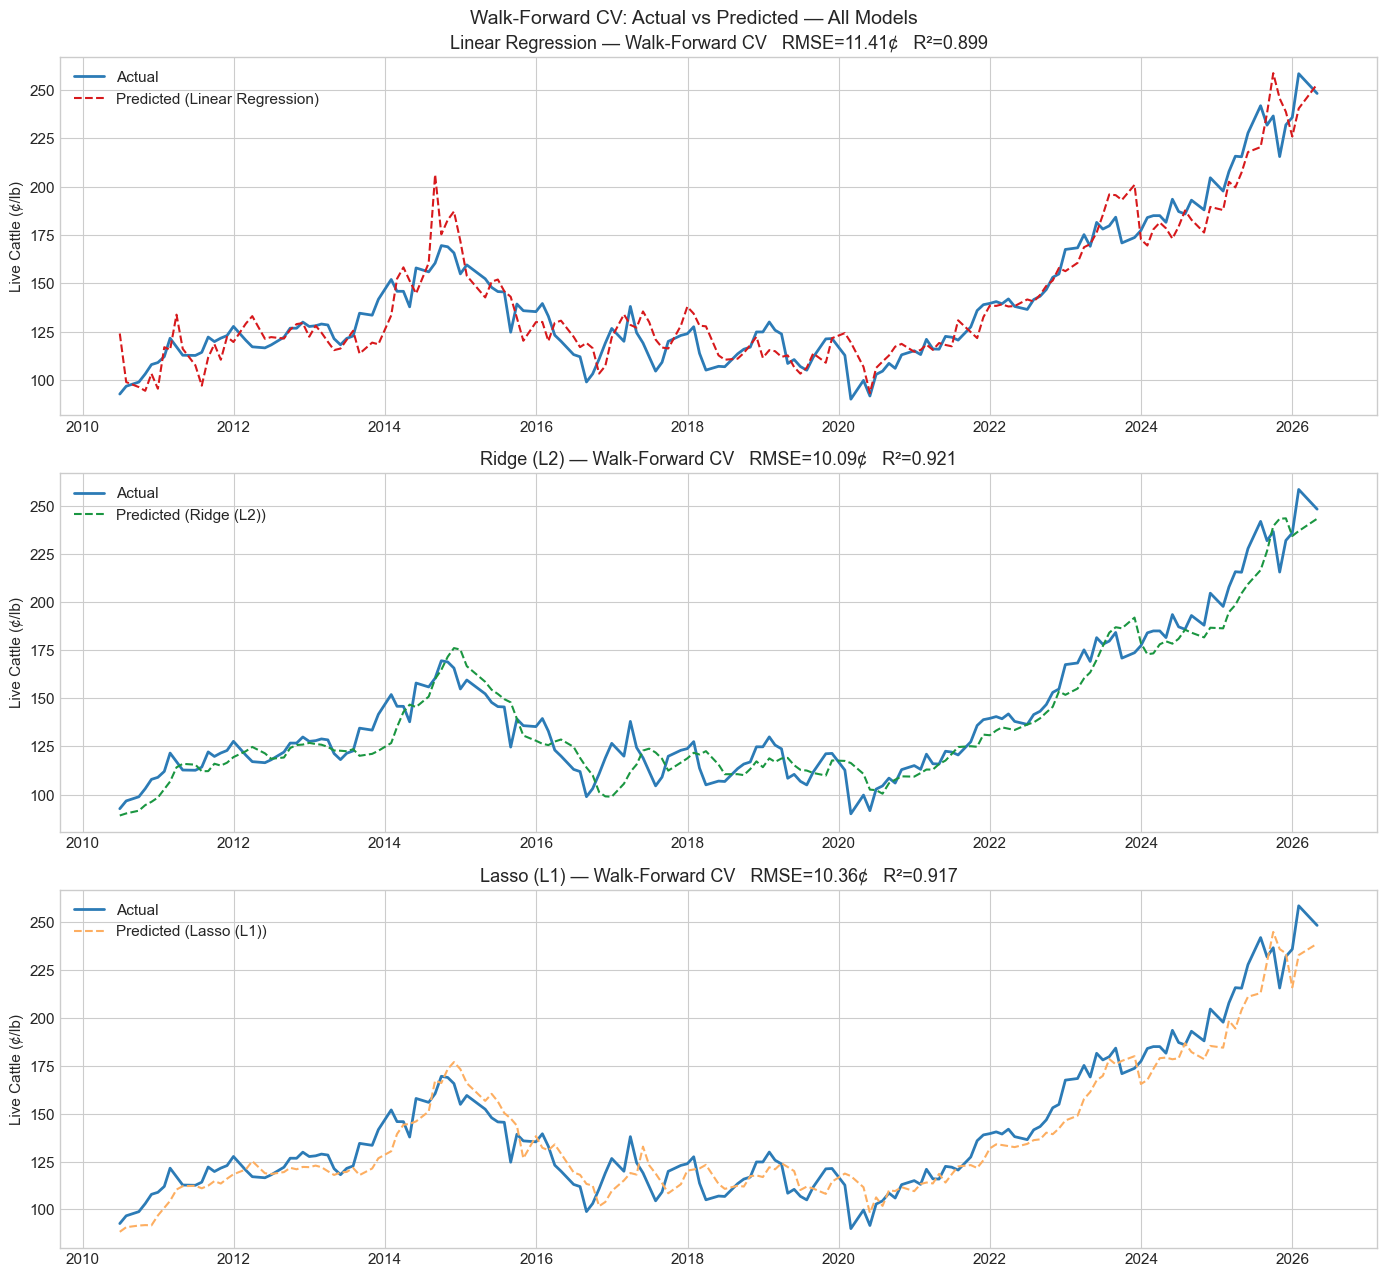

In [78]:
if futures is not None:
    fig, axes = plt.subplots(3, 1, figsize=(14, 13))
    colors_m = {'Linear Regression': '#d7191c', 'Ridge (L2)': '#1a9641', 'Lasso (L1)': '#fdae61'}

    for ax, (name, wf_df) in zip(axes, wf_dfs.items()):
        ax.plot(wf_df.index, wf_df['actual'],    color='#2c7bb6', linewidth=2,   label='Actual')
        ax.plot(wf_df.index, wf_df['predicted'], color=colors_m[name], linewidth=1.5,
                linestyle='--', label=f'Predicted ({name})')
        rmse = np.sqrt(mean_squared_error(wf_df['actual'], wf_df['predicted']))
        r2   = r2_score(wf_df['actual'], wf_df['predicted'])
        ax.set_title(f'{name} — Walk-Forward CV   RMSE={rmse:.2f}¢   R²={r2:.3f}')
        ax.set_ylabel('Live Cattle (¢/lb)')
        ax.legend(loc='upper left')
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.suptitle('Walk-Forward CV: Actual vs Predicted — All Models', fontsize=14)
    plt.tight_layout()
    plt.show()

### 4.7 Residual Analysis

Good residuals should be: (1) centered near zero, (2) approximately normally distributed, (3) not autocorrelated.
Autocorrelated residuals indicate the model is missing a systematic pattern.

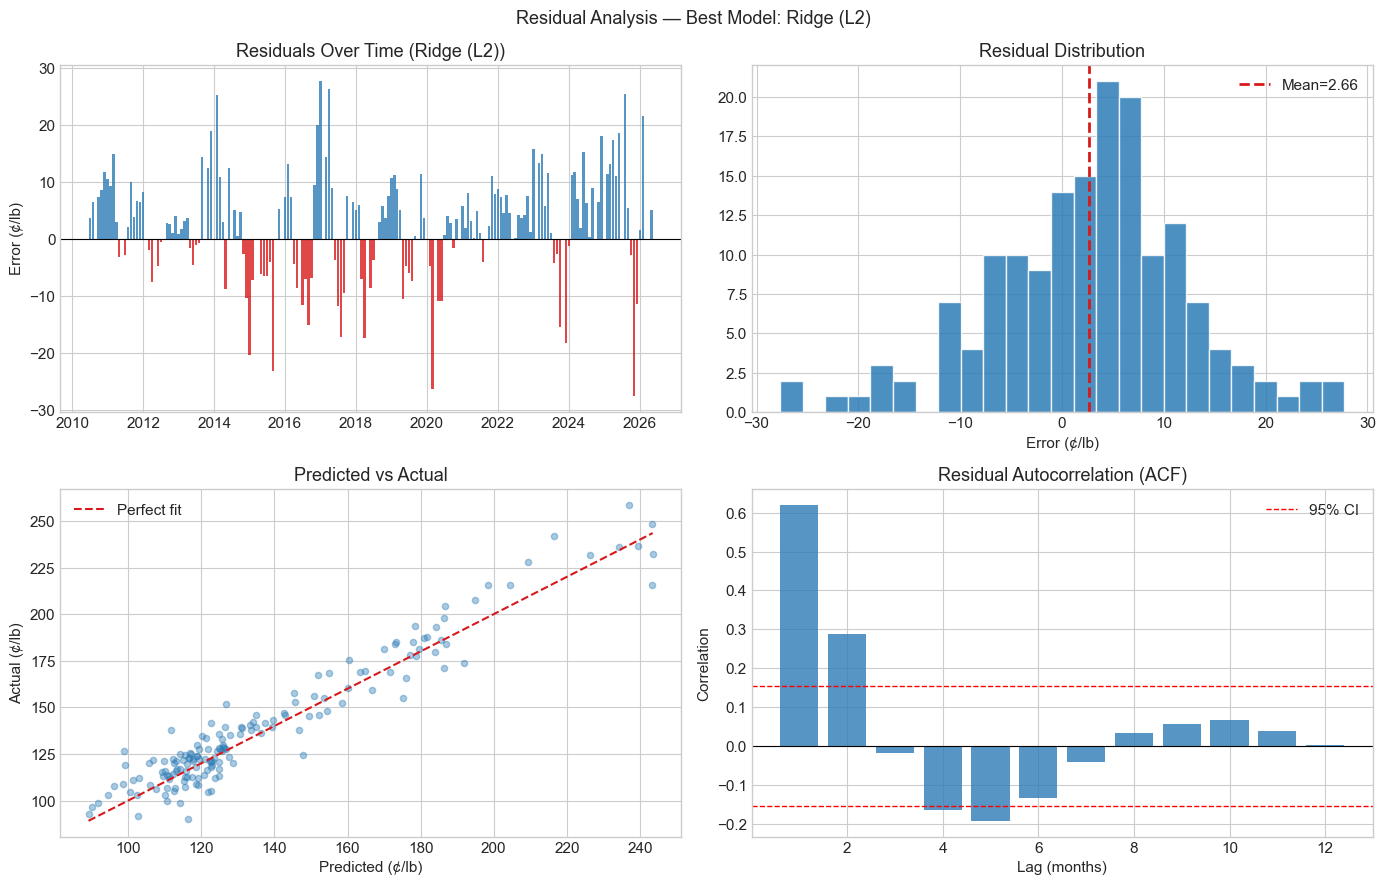

Best model: Ridge (L2)
Residual mean:  2.656 (ideal = 0)
Residual std:   9.766
Lag-1 residual autocorrelation: 0.619 (ideal < |0.2|)


In [79]:
if futures is not None:
    best_name = min(wf_dfs, key=lambda n: np.sqrt(
        mean_squared_error(wf_dfs[n]['actual'], wf_dfs[n]['predicted'])))
    best_df = wf_dfs[best_name]
    resid   = best_df['actual'] - best_df['predicted']

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # Residuals over time
    axes[0,0].bar(resid.index, resid,
                  color=['#2c7bb6' if r >= 0 else '#d7191c' for r in resid],
                  width=25, alpha=0.8)
    axes[0,0].axhline(0, color='black', linewidth=0.8)
    axes[0,0].set_title(f'Residuals Over Time ({best_name})')
    axes[0,0].set_ylabel('Error (¢/lb)')

    # Residual distribution
    axes[0,1].hist(resid, bins=25, color='#2c7bb6', edgecolor='white', alpha=0.85)
    axes[0,1].axvline(resid.mean(), color='#d7191c', linewidth=2, linestyle='--',
                      label=f'Mean={resid.mean():.2f}')
    axes[0,1].set_title('Residual Distribution')
    axes[0,1].set_xlabel('Error (¢/lb)')
    axes[0,1].legend()

    # Predicted vs actual scatter
    axes[1,0].scatter(best_df['predicted'], best_df['actual'], alpha=0.4, color='#2c7bb6', s=20)
    mn, mx = best_df['predicted'].min(), best_df['predicted'].max()
    axes[1,0].plot([mn, mx], [mn, mx], color='#d7191c', linewidth=1.5, linestyle='--', label='Perfect fit')
    axes[1,0].set_title('Predicted vs Actual')
    axes[1,0].set_xlabel('Predicted (¢/lb)')
    axes[1,0].set_ylabel('Actual (¢/lb)')
    axes[1,0].legend()

    # Residual ACF
    lags = list(range(1, 13))
    acf_resid = [resid.autocorr(lag=l) for l in lags]
    ci_r = 1.96 / np.sqrt(len(resid))
    axes[1,1].bar(lags, acf_resid, color='#2c7bb6', alpha=0.8)
    axes[1,1].axhline(0,     color='black', linewidth=0.8)
    axes[1,1].axhline( ci_r, color='red',   linewidth=1, linestyle='--', label='95% CI')
    axes[1,1].axhline(-ci_r, color='red',   linewidth=1, linestyle='--')
    axes[1,1].set_title('Residual Autocorrelation (ACF)')
    axes[1,1].set_xlabel('Lag (months)')
    axes[1,1].set_ylabel('Correlation')
    axes[1,1].legend()

    plt.suptitle(f'Residual Analysis — Best Model: {best_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"Best model: {best_name}")
    print(f"Residual mean:  {resid.mean():.3f} (ideal = 0)")
    print(f"Residual std:   {resid.std():.3f}")
    print(f"Lag-1 residual autocorrelation: {resid.autocorr(1):.3f} (ideal < |0.2|)")

### 4.8 Model Comparison Summary

In [80]:
if futures is not None:
    print("=" * 70)
    print("FINAL MODEL COMPARISON — Walk-Forward CV")
    print("=" * 70)
    print(f"{'Model':<22} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'MAPE':>8} {'DirAcc':>9}")
    print("-" * 70)
    summary_rows = []
    for name, wf_df in wf_dfs.items():
        rmse = np.sqrt(mean_squared_error(wf_df['actual'], wf_df['predicted']))
        mae  = mean_absolute_error(wf_df['actual'], wf_df['predicted'])
        r2   = r2_score(wf_df['actual'], wf_df['predicted'])
        mape = np.mean(np.abs((wf_df['actual'] - wf_df['predicted']) / wf_df['actual'])) * 100
        da   = np.mean(np.sign(np.diff(wf_df['actual'].values)) ==
                       np.sign(np.diff(wf_df['predicted'].values))) * 100
        summary_rows.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2,
                              'MAPE': mape, 'DirAcc': da})
        print(f"{name:<22} {rmse:>7.2f}¢ {mae:>7.2f}¢ {r2:>8.3f} {mape:>7.1f}% {da:>8.1f}%")

    best = min(summary_rows, key=lambda r: r['RMSE'])
    print(f"\n→ Best model by RMSE: {best['Model']}")

    # Target benchmark comparison
    print("\nSuccess Criteria Check:")
    print(f"  RMSE  < 5¢/lb:   {'✅' if best['RMSE'] < 5  else '❌'}  ({best['RMSE']:.2f}¢)")
    print(f"  MAE   < 3¢/lb:   {'✅' if best['MAE']  < 3  else '❌'}  ({best['MAE']:.2f}¢)")
    print(f"  R²    ≥ 0.75:    {'✅' if best['R2']   >= 0.75 else '❌'}  ({best['R2']:.3f})")
    print(f"  DirAcc > 60%:    {'✅' if best['DirAcc'] > 60 else '❌'}  ({best['DirAcc']:.1f}%)")

FINAL MODEL COMPARISON — Walk-Forward CV
Model                      RMSE      MAE       R²     MAPE    DirAcc
----------------------------------------------------------------------
Linear Regression        11.41¢    8.72¢    0.899     6.4%     49.7%
Ridge (L2)               10.09¢    7.98¢    0.921     5.8%     52.8%
Lasso (L1)               10.36¢    8.50¢    0.917     6.1%     54.7%

→ Best model by RMSE: Ridge (L2)

Success Criteria Check:
  RMSE  < 5¢/lb:   ❌  (10.09¢)
  MAE   < 3¢/lb:   ❌  (7.98¢)
  R²    ≥ 0.75:    ✅  (0.921)
  DirAcc > 60%:    ❌  (52.8%)


---
## Phase 6: Deployment

The deployment phase operationalizes the trained model as an interactive web application. The app allows practitioners to enter current market data and receive a 1-month ahead Live Cattle futures price forecast without writing any code.

### Architecture
| Component | Technology |
|-----------|------------|
| Model serving | `joblib` serialized Ridge/Lasso pipeline |
| Web UI | Streamlit (Python-only, no HTML/CSS/JS) |
| Hosting | Streamlit Community Cloud (free, GitHub-connected) |
| Inputs | Last 3 months of key prices + current supply metrics |
| Output | Predicted LE price (¢/lb) + directional signal |

### Deployment Steps
1. Run **Section 6.1** below to save model artifacts (`.pkl` files)
2. Run **Section 6.2** to auto-generate `app.py`
3. Push everything to GitHub: `beef_price_prediction_eda.ipynb`, `app.py`, `requirements.txt`, and all `.pkl` files
4. Go to **share.streamlit.io** → Connect your GitHub repo → Deploy

### 6.1 Save Model Artifacts

In [81]:
if futures is not None:
    import joblib, os

    # ── Identify best model by RMSE ───────────────────────────────────────────
    best_name = min(summary_rows, key=lambda r: r['RMSE'])['Model']
    model_map = {'Linear Regression': models['Linear Regression'],
                 'Ridge (L2)': models['Ridge (L2)'],
                 'Lasso (L1)': models['Lasso (L1)']}
    best_model = model_map[best_name]

    # Refit best model on FULL dataset (train+test) for deployment
    X_full = X_tr_f_sc = scaler.fit_transform(X_te_f if False else
                         pd.concat([X_tr_f, X_te_f]))
    y_full = pd.concat([y_train.loc[X_tr_f.index], y_test.loc[X_te_f.index]])
    best_model.fit(X_full, y_full)

    # ── Compute feature medians (fallback defaults for app inputs) ────────────
    feature_medians = dict(pd.concat([X_tr_f, X_te_f]).median())

    # ── Save artifacts ────────────────────────────────────────────────────────
    joblib.dump(best_model,       'cattle_price_model.pkl')
    joblib.dump(scaler,           'scaler.pkl')
    joblib.dump(final_features,   'feature_cols.pkl')
    joblib.dump(feature_medians,  'feature_medians.pkl')

    print(f"✅ Saved: cattle_price_model.pkl  ({best_name})")
    print(f"✅ Saved: scaler.pkl")
    print(f"✅ Saved: feature_cols.pkl  ({len(final_features)} features)")
    print(f"✅ Saved: feature_medians.pkl")
    print()
    print("These 4 files + app.py must be committed to your GitHub repo for deployment.")

✅ Saved: cattle_price_model.pkl  (Ridge (L2))
✅ Saved: scaler.pkl
✅ Saved: feature_cols.pkl  (33 features)
✅ Saved: feature_medians.pkl

These 4 files + app.py must be committed to your GitHub repo for deployment.


### 6.2 Streamlit App ()

In [82]:
import os

# app.py is included alongside this notebook in the GitHub repo.
# Run this cell to confirm it is present in your working directory.
app_path = os.path.join(os.getcwd(), 'app.py')
if os.path.exists(app_path):
    print(f"✅ app.py found at: {app_path}")
else:
    print("⚠  app.py not found in current directory.")
    print("   Download it from the GitHub repo and place it next to this notebook.")

print()
print("To run the Streamlit app locally:")
print("  1.  pip install streamlit")
print("  2.  streamlit run app.py")
print()
print("To deploy on Streamlit Community Cloud:")
print("  1.  Push to GitHub: notebook + app.py + requirements.txt + *.pkl files")
print("  2.  Go to share.streamlit.io")
print("  3.  New app → select repo → main file = app.py → Deploy")
print("  4.  A public live URL is generated automatically")

✅ app.py found at: /Users/brianplace/Python/Capstone/app.py

To run the Streamlit app locally:
  1.  pip install streamlit
  2.  streamlit run app.py

To deploy on Streamlit Community Cloud:
  1.  Push to GitHub: notebook + app.py + requirements.txt + *.pkl files
  2.  Go to share.streamlit.io
  3.  New app → select repo → main file = app.py → Deploy
  4.  A public live URL is generated automatically


### 6.3 Requirements File

In [83]:
REQ = """streamlit>=1.35.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.3.0
joblib>=1.3.0
openpyxl>=3.1.0
yfinance>=0.2.0
"""

with open('requirements.txt', 'w') as f:
    f.write(REQ)

print("✅ requirements.txt written")
print()
print("GitHub repo should contain:")
for fname in ['beef_price_prediction_eda.ipynb', 'app.py', 'requirements.txt',
              'cattle_price_model.pkl', 'scaler.pkl', 'feature_cols.pkl', 'feature_medians.pkl']:
    print(f"  {fname}")

✅ requirements.txt written

GitHub repo should contain:
  beef_price_prediction_eda.ipynb
  app.py
  requirements.txt
  cattle_price_model.pkl
  scaler.pkl
  feature_cols.pkl
  feature_medians.pkl


---
## Summary & Key EDA Findings

| Finding | Model Implication |
|---------|-------------------|
| Strong lag-1 autocorrelation in LE price | Lagged price is the single most important feature |
| Clear seasonal pattern (spring/summer premium) | Month dummy variables are required |
| Feeder Cattle has the highest correlation with Live Cattle | Include as a primary feature |
| Cold storage leads price by 1–2 months | Use lagged cold storage, not concurrent |
| Corn price positively correlated with LE | Feed cost signal; include lag-1 and lag-2 |
| Multi-year cattle cycles visible in production trend | Rolling 12-month averages capture cycle signal |

### Confirmed Model Feature Set
1. Lagged Live Cattle price (lag 1, 2, 3)
2. Lagged Feeder Cattle price (lag 1, 2, 3) + rolling means
3. Lagged Corn price (lag 1, 2, 3) + rolling means
4. Lagged Beef production, YoY change
5. Lagged Cattle slaughter, YoY change
6. Lagged Cold storage, YoY change
7. Month dummy variables (seasonality)
8. Rolling 3/6/12-month means for key price series

---
*Notebook: US Live Cattle Futures Price Prediction — CRISP-DM Capstone*
*Author: Brian Place | Data: USDA ERS + CME via yfinance | July 2026*